# 06 · Naive Bayes Ailesi (Naive Bayes Family)
**Classical ML Lab** · Bayes Teoremi'nin "Naif" Ama Şaşırtıcı Derecede Güçlü Uygulaması

---
> **Bu notebook'ta ne öğreneceğiz?**
> `03_linear_classification_family`'de Lojistik Regresyon (ayırt edici/discriminative) ile LDA/QDA (üretici/generative) arasındaki farkı görmüştük. Naive Bayes de LDA/QDA gibi **üretici** bir modeldir — $P(y\mid x)$'i doğrudan modellemek yerine $P(x\mid y)$ ve $P(y)$'yi öğrenip Bayes teoremiyle ters çevirir. Ama LDA/QDA'nın aksine, özellikler arasındaki **tüm korelasyon yapısını** (kovaryans matrisini) görmezden gelip her özelliğin sınıf içinde birbirinden **bağımsız** olduğunu varsayar — bu "naif" (naive) varsayım, teoride sıklıkla yanlış olsa da pratikte şaşırtıcı derecede iyi çalışır. Bu notebook'ta Bayes teoremini hatırlayıp naif bağımsızlık varsayımını kuracak, ardından dört ana varyantı (Gaussian, Multinomial, Bernoulli, Complement) hem sürekli hem metin verisi üzerinde uygulayacak, Laplace/Lidstone düzeltmesini ve sayısal kararlılık için log-olasılık hesabını öğrenecek, ve metin sınıflandırmanın standart Bag-of-Words / TF-IDF pipeline'ını kuracağız.

**Önkoşul:** `03_linear_classification_family` (Bayes teoremi, LDA/QDA'nın üretici model mantığı)
**Veri:** Sonar — Mines vs. Rocks (UCI, 208 örnek, 60 sürekli sonar-sinyali özniteliği, sınıf dengeli) · SMS Spam Collection (UCI, 5.572 SMS, ikili metin sınıflandırma, sınıflar doğal olarak dengesiz — %86.6 ham / %13.4 spam)
**Araçlar:** Python (`scikit-learn`, `numpy`, `pandas`, `matplotlib`/`seaborn`), R (`e1071`), SQL (DuckDB)

---
## 1 · Bayes Teoremi ve "Naif" Bağımsızlık Varsayımı

**Bayes teoremi**, bir olayın olasılığını yeni kanıt ışığında güncellememizi sağlar:
$$P(y \mid x) = \frac{P(x \mid y)\, P(y)}{P(x)}$$

Sınıflandırma bağlamında $y$ sınıf etiketi, $x = (x_1, \dots, x_d)$ ise öznitelik vektörüdür. $P(y\mid x)$'e **posterior** (kanıt sonrası inanç), $P(y)$'ye **prior** (kanıt öncesi inanç), $P(x\mid y)$'ye **likelihood** (o sınıfta bu veriyi gözlemleme olasılığı) denir. $P(x)$ tüm sınıflar için sabit olduğundan, sınıflandırma kararı için göz ardı edilebilir:
$$\hat{y} = \underset{y}{\text{argmax}}\; P(x \mid y)\, P(y)$$

**Somut sayısal örnek (tıbbi tarama testi):** Bir hastalığın toplumdaki yaygınlığı (prior) $P(\text{hasta})=0.01$ olsun. Test, gerçekten hasta olanların $\%95$'ini doğru tespit ediyor (duyarlılık/sensitivity: $P(+\mid \text{hasta})=0.95$) ve sağlıklı olanların $\%90$'ını doğru "negatif" olarak işaretliyor (özgüllük/specificity: $P(-\mid \text{sağlıklı})=0.90$, yani yanlış pozitif oranı $P(+\mid\text{sağlıklı})=0.10$). Testi pozitif çıkan birinin **gerçekten hasta olma olasılığı** nedir?
$$P(\text{hasta}\mid +) = \frac{P(+\mid\text{hasta})\,P(\text{hasta})}{P(+\mid\text{hasta})\,P(\text{hasta}) + P(+\mid\text{sağlıklı})\,P(\text{sağlıklı})} = \frac{0.95 \times 0.01}{0.95\times 0.01 + 0.10\times 0.99} \approx 0.088$$

Test "%95 doğru" olmasına rağmen pozitif çıkan birinin hasta olma olasılığı sadece **%8.8**'dir — düşük prevalans (düşük prior), yanlış pozitiflerin mutlak sayıca gerçek pozitiflerden çok daha fazla olmasına yol açar. Bu, Bayes teoreminin en klasik ve en çok yanlış yorumlanan sonucudur (bkz. "base rate fallacy") ve tıbbi tarama, HIV/kanser testleri, adli bilişimde DNA eşleştirme gibi gerçek dünya kararlarında kritik önemdedir.

**Sınıflandırmaya genelleme — neden "naif"?** $x$ çok boyutlu olduğunda ($d$ öznitelik), $P(x\mid y) = P(x_1, x_2, \dots, x_d \mid y)$ ortak dağılımını tahmin etmek gerekir — bu, öznitelikler arasındaki **tüm** etkileşimleri (kovaryans, üçlü etkileşimler, ...) kapsayan katlanarak büyüyen bir parametre uzayı gerektirir (tıpkı `03`'te QDA'nın her sınıf için ayrı bir $d\times d$ kovaryans matrisi tahmin etmesi gibi, ama daha da genel). Naive Bayes, bunu **radikal bir sadeleştirmeyle** çözer — **koşullu bağımsızlık varsayımı**:
$$P(x_1, \dots, x_d \mid y) = \prod_{i=1}^{d} P(x_i \mid y)$$

Yani sınıf bilindiğinde, özniteliklerin birbirinden **bağımsız** olduğu varsayılır. Bu neredeyse her zaman **yanlıştır** (örn. bir e-postada "kazandınız" kelimesi geçiyorsa "ödül" kelimesinin de geçme olasılığı artar — bağımsız değildir), ama Domingos & Pazzani'nin (1997) gösterdiği gibi, sınıflandırma **kararı** (hangi sınıfın en yüksek posterior'a sahip olduğu) genellikle doğru kalır çünkü bağımlılıklardan kaynaklanan hatalar çoğunlukla tüm sınıflarda benzer yönde "sistematik" olarak birikir ve göreli sıralamayı bozmaz — 0-1 kayıp (doğru/yanlış sınıflandırma) altında optimal olabilir, olasılık tahminlerinin kalibrasyonu bozuk olsa bile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import duckdb
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, precision_recall_curve, roc_curve, auc,
                              f1_score, log_loss, recall_score, precision_score)
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

---
### Bayes teoremini elle hesaplayalım (tıbbi tarama örneği)

Yukarıdaki formülü koda dökelim — bu, tüm notebook boyunca kullanacağımız "posterior $\propto$ likelihood $\times$ prior" mantığının en yalın hâli.

In [2]:
def bayes_posterior(prior_pos, sensitivity, false_positive_rate):
    """P(hasta | test+) hesaplar."""
    prior_neg = 1 - prior_pos
    p_pos_given_pos_class = sensitivity * prior_pos
    p_pos_given_neg_class = false_positive_rate * prior_neg
    evidence = p_pos_given_pos_class + p_pos_given_neg_class
    posterior = p_pos_given_pos_class / evidence
    return posterior

prevalence = 0.01 # Prior (hastalık prevalansı): P(hasta)
sensitivity = 0.95 # Duyarlılık (sensitivity): P(+|hasta)
specificity = 0.90 # Spesifiklik (specificity): P(-|sağlıklı)
fpr = 1 - specificity # Yanlış pozitif oranı: P(+|sağlıklı)

posterior = bayes_posterior(prevalence, sensitivity, fpr)
print(f"Prior (hastalık prevalansı):        P(hasta) = {prevalence:.1%}")
print(f"Duyarlılık (sensitivity):            P(+|hasta) = {sensitivity:.1%}")
print(f"Yanlış pozitif oranı:                P(+|sağlıklı) = {fpr:.1%}")
print(f"--> Posterior:                       P(hasta|+) = {posterior:.1%}")
print()
print("YORUM: Test 'yüzde 95 doğru' olsa da, düşük prevalans nedeniyle pozitif")
print("çıkan birinin gerçekten hasta olma olasılığı sadece ~%9. Bayes teoremi,")
print("'prior'ın (temel oran) sonuca ne kadar güçlü etki ettiğini gösteriyor.")

Prior (hastalık prevalansı):        P(hasta) = 1.0%
Duyarlılık (sensitivity):            P(+|hasta) = 95.0%
Yanlış pozitif oranı:                P(+|sağlıklı) = 10.0%
--> Posterior:                       P(hasta|+) = 8.8%

YORUM: Test 'yüzde 95 doğru' olsa da, düşük prevalans nedeniyle pozitif
çıkan birinin gerçekten hasta olma olasılığı sadece ~%9. Bayes teoremi,
'prior'ın (temel oran) sonuca ne kadar güçlü etki ettiğini gösteriyor.


---
## 2 · Genel Sınıflandırma Çerçevesi: MAP Kuralı ve Log-Olasılıklar

Naive bağımsızlık varsayımıyla karar kuralı şu hâle gelir (**Maximum A Posteriori**, MAP):
$$\hat{y} = \underset{y}{\text{argmax}}\; P(y) \prod_{i=1}^{d} P(x_i \mid y)$$

**Sayısal kararlılık sorunu:** Onlarca/yüzlerce öznitelik için olasılıkların ($0 < P(x_i\mid y) < 1$) çarpımı, kayan nokta (floating-point) hassasiyetinin altına inip **sayısal alt taşma (underflow)** yaratır — örneğin 1000 kelimelik bir metinde her biri $\approx 0.01$ olasılıklı 1000 terim çarpılırsa sonuç $10^{-2000}$ civarına düşer, bu da bilgisayarda `0.0`'a yuvarlanır. Çözüm, çarpımı **log-uzayında toplama** çevirmektir ($\log$ monoton artan olduğundan argmax değişmez):
$$\hat{y} = \underset{y}{\text{argmax}}\; \left[\log P(y) + \sum_{i=1}^{d} \log P(x_i \mid y)\right]$$

`scikit-learn`'ün tüm Naive Bayes implementasyonları (ve neredeyse tüm üretim kütüphaneleri) hesaplamayı bu şekilde, log-uzayında yapar — `predict_log_proba()` metodu bu ham log-posterior değerlerine doğrudan erişim sağlar. Dört ana varyant, sadece $P(x_i\mid y)$'yi **nasıl modellediği** açısından birbirinden ayrılır:

| Varyant | Öznitelik tipi | $P(x_i\mid y)$ modeli | Tipik kullanım |
|---|---|---|---|
| **GaussianNB** | Sürekli | Normal (Gauss) dağılım | Sensör verisi, biyolojik ölçümler |
| **MultinomialNB** | Sayım (≥0 tam sayı) | Multinomial dağılım | Kelime sayıları, metin sınıflandırma |
| **BernoulliNB** | İkili (0/1) | Bernoulli dağılım | Kelime varlığı/yokluğu, kısa metin |
| **ComplementNB** | Sayım (≥0 tam sayı) | Multinomial'ın "tamamlayıcı" düzeltmesi | Dengesiz (imbalanced) metin sınıflandırma |

---
## 3 · Gaussian Naive Bayes

Sürekli öznitelikler için, her sınıf $y$ ve her öznitelik $i$ için ayrı bir tek-boyutlu Normal dağılım varsayılır:
$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}} \exp\left(-\frac{(x_i - \mu_{y,i})^2}{2\sigma_{y,i}^2}\right)$$

$\mu_{y,i}$ ve $\sigma_{y,i}^2$, eğitim verisinden **sınıf $y$'ye ait örneklerin $i$. özniteliğinin ortalaması ve varyansı** olarak doğrudan (kapalı formda, iteratif optimizasyon gerekmeden) tahmin edilir — bu, GaussianNB'yi eğitim açısından son derece hızlı yapar (tek geçişte, $O(nd)$).

**`03_linear_classification_family`'deki QDA ile karşılaştırma:** QDA da her sınıf için Gauss dağılımı varsayar, ama **tam kovaryans matrisi** ($d\times d$, öznitelikler arası tüm korelasyonlarla) kullanır. GaussianNB ise kovaryans matrisini **köşegen (diagonal)** kabul eder — yani $\Sigma_y = \text{diag}(\sigma_{y,1}^2, \dots, \sigma_{y,d}^2)$, öznitelikler arası korelasyon sıfırlanır. Bu, GaussianNB'yi QDA'nın $O(d^2)$ yerine $O(d)$ parametreyle çalışan, çok daha hafif ama korelasyonlu özniteliklerde daha yanlı (biased) bir özel hâli yapar.

**Endüstride nerede kullanılır?** Gerçek zamanlı sensör/sinyal sınıflandırma (sonar/radar sinyali "hedef mi gürültü mü", titreşim sensörleriyle arıza tespiti), tıbbi teşhiste sürekli biyobelirteç (biomarker) ölçümleriyle hızlı ön-tarama (özellik sayısı örnek sayısına göre büyük olduğunda tam kovaryans tahmini güvenilmez hâle gelir, GaussianNB'nin sadeliği avantaja dönüşür), IoT cihazlarında düşük hesaplama gücüyle gerçek zamanlı anomali/durum sınıflandırma.

---
## 4 · Multinomial Naive Bayes

Sayım verisi (ör. bir dokümanda her kelimenin kaç kez geçtiği) için öznitelikler multinomial dağılımdan geldiği varsayılır. Sınıf $y$ için her öznitelik (kelime) $i$'nin bir $\theta_{y,i}$ olasılığı vardır ($\sum_i \theta_{y,i} = 1$), ve $x$ (bir dokümanın kelime-sayım vektörü) verildiğinde log-likelihood:
$$\log P(x \mid y) = \text{const} + \sum_{i=1}^{d} x_i \log \theta_{y,i}$$

$\theta_{y,i}$, ham hâliyle basitçe "sınıf $y$'deki tüm dokümanlarda $i$. kelimenin görülme oranı" olurdu:
$$\theta_{y,i} = \frac{N_{y,i}}{N_y} \qquad N_{y,i} = \sum_{x \in y} x_i \quad(\text{sınıf } y\text{'de } i\text{. kelimenin toplam sayımı}), \quad N_y = \sum_i N_{y,i}$$

**Sorun — sıfır olasılık:** Eğitim setinde sınıf $y$'de hiç geçmeyen bir kelime ($N_{y,i}=0$) test setinde karşımıza çıkarsa, $\theta_{y,i}=0$ olur ve bu tek kelime **tüm** log-olasılık toplamını $-\infty$ yaparak diğer tüm kanıtı geçersiz kılar. **Laplace düzeltmesi (additive/Laplace smoothing)** her sayıma küçük bir sabit ekleyerek bunu önler:
$$\theta_{y,i} = \frac{N_{y,i} + \alpha}{N_y + \alpha d}$$

$\alpha=1$ klasik Laplace düzeltmesidir ("hayali" bir gözlem eklemek gibi düşünülebilir); $0<\alpha<1$ ise **Lidstone düzeltmesi** olarak adlandırılır ve daha hafif bir düzeltme sağlar. `scikit-learn`'de `alpha` hiperparametresi bunu kontrol eder.

**Endüstride nerede kullanılır?** Naive Bayes'in **tarihsel olarak en bilinen** uygulaması: e-posta spam filtreleme (1990'ların sonunda Sahami ve arkadaşlarının 1998 tarihli çalışması ve sonrasında Paul Graham'ın popülerleştirdiği yaklaşım) — bugün hâlâ birçok basit/gömülü spam filtresinin temelini oluşturur. Ayrıca haber makalelerini kategoriye göre otomatik yönlendirme (spor/ekonomi/siyaset), müşteri destek taleplerini departmana göre sınıflandırma, ve büyük ölçekli, düşük gecikmeli (low-latency) metin sınıflandırma gerektiren her senaryoda ilk denenecek temel (baseline) modeldir.

---
## 5 · Bernoulli Naive Bayes

MultinomialNB "kaç kez geçti"yi (sayım) modellerken, BernoulliNB sadece "geçti mi geçmedi mi"yi (ikili varlık/yokluk) modeller. Her öznitelik $i$, sınıf $y$'de bir Bernoulli değişkenidir ($x_i \in \{0,1\}$):
$$P(x_i \mid y) = p_{y,i}^{\,x_i}\,(1-p_{y,i})^{\,1-x_i}$$

Kritik fark: BernoulliNB, bir kelimenin **açıkça yokluğunu** ($x_i=0$ terimi $1-p_{y,i}$ olarak) modele dahil ederken, MultinomialNB yokluğu (sayım $0$) formülde etkisiz bırakır (çünkü $x_i \log\theta_{y,i}$ teriminde $x_i=0$ ise katkı sıfırdır). Bu, BernoulliNB'yi **"bir kelimenin geçmemesi de bilgi taşır"** varsayımının önemli olduğu senaryolarda (kısa metinler, sabit/kapalı kelime dağarcığı) MultinomialNB'den ayırır.

Laplace/Lidstone düzeltmesi burada da aynı mantıkla uygulanır: $p_{y,i} = \dfrac{N_{y,i} + \alpha}{N_y + 2\alpha}$ (payda $2\alpha$'dır çünkü Bernoulli'de sadece 2 olası değer — 0 ve 1 — vardır).

**Endüstride nerede kullanılır?** Kısa metin sınıflandırma (SMS/tweet spam tespiti — mesaj kısa olduğundan bir kelimenin *hiç* geçmemesi güçlü bir sinyal olabilir), ikili öznitelik setleriyle çalışan biyoinformatik uygulamaları (belirli bir gen mutasyonunun/varyantının hastada var/yok olması), ve bir e-ticaret kullanıcısının belirli ürün kategorilerini "hiç ziyaret etmemiş olması"nın da bir sinyal taşıdığı davranışsal segmentasyon modelleri.

---
## 6 · Complement Naive Bayes

Rennie ve arkadaşlarının (2003) "Tackling the Poor Assumptions of Naive Bayes Text Classifiers" makalesinde tanıttığı ComplementNB, MultinomialNB'nin **dengesiz (imbalanced) sınıf dağılımlarında** sistematik olarak baskın sınıfa yanlı davranma sorununu düzeltmek için tasarlanmıştır. Sezgi şu: bir sınıfın kendi verisinden parametre tahmin etmek yerine, o sınıfın **tamamlayıcısından** (complement — "bu sınıfa AİT OLMAYAN her şey") tahmin edilir:
$$\theta_{y,i}^{\,\text{comp}} = \frac{\alpha + \sum_{j \neq y} N_{j,i}}{\alpha d + \sum_{j \neq y} N_j} \qquad w_{y,i} = \log \theta_{y,i}^{\,\text{comp}}$$

Bir dokümanı sınıflandırırken, bu ağırlıklarla **en düşük** skoru veren sınıf seçilir (çünkü tamamlayıcı ile en az uyumlu olan sınıf, aslında dokümanın gerçek sınıfına en yakın olandır). Küçük (azınlık) sınıflar, kendi az sayıdaki örneğinden değil, **çok daha büyük olan "geri kalan her şey" verisinden** güvenilir istatistik tahmin ettiğinden, tahminler çok daha az varyanslı ve baskın sınıfa daha az yanlı olur.

**Endüstride nerede kullanılır?** Dolandırıcılık/spam tespiti gibi pozitif sınıfın doğası gereği nadir olduğu (örn. %1-5) ikili sınıflandırma problemleri, dengesiz büyüklükte kategorilere sahip çok-sınıflı haber/doküman kategorizasyonu (bazı kategoriler binlerce, bazıları onlarca örnek içerebilir), ve genel olarak "MultinomialNB'nin ilk deneme sonucu hayal kırıklığı yarattığında denenecek ikinci model" — scikit-learn dokümantasyonu bunu metin sınıflandırma için MultinomialNB'ye **tercih edilebilir bir varsayılan** olarak önerir.

---
## 7 · Metin Sınıflandırma Pipeline'ı: Bag-of-Words ve TF-IDF

Ham metni Naive Bayes'in beklediği sayısal öznitelik vektörüne dönüştürmek için standart adımlar:

1. **Tokenization:** Metni kelimelere (token) ayırma, küçük harfe çevirme, noktalama temizleme.
2. **Bag-of-Words (BoW):** Kelime dağarcığındaki (vocabulary) her kelime bir öznitelik (sütun) olur; her doküman, o kelimenin dokümanda kaç kez geçtiğinin sayıldığı bir vektöre dönüşür — kelime **sırası tamamen kaybolur** (bu yüzden "bag" — çuval). `scikit-learn`'de `CountVectorizer`.
3. **Binarize:** BoW sayımlarını $0/1$'e indirger (kelime var mı yok mu) — BernoulliNB'nin doğrudan beklediği format. `CountVectorizer(binary=True)` veya `Binarizer`.
4. **TF-IDF (Term Frequency – Inverse Document Frequency):** Ham sayım yerine, bir kelimenin dokümandaki sıklığını ($\text{TF}$) kelimenin **tüm korpüste ne kadar nadir** olduğuyla ($\text{IDF} = \log\frac{N}{\text{df}_i}$, $\text{df}_i$ = kelimenin geçtiği doküman sayısı) çarpıp ağırlıklandırır:
$$\text{tfidf}(i, doc) = \text{tf}(i,doc) \times \log\frac{N}{\text{df}_i}$$
   Sezgi: "the", "and" gibi hemen her dokümanda geçen kelimeler düşük ağırlık alır (ayırt edici değiller), nadir ama o dokümana özgü kelimeler yüksek ağırlık alır. `scikit-learn`'de `TfidfVectorizer`.

**Önemli teknik not:** TF-IDF ağırlıkları artık tam sayı sayım değil, ondalıklı ağırlıklardır — bu, MultinomialNB'nin varsaydığı "gerçek multinomial sayım" modelinden matematiksel olarak sapar (multinomial dağılım tanım gereği tam sayı sayımlar üzerine kuruludur). Buna rağmen pratikte MultinomialNB + TF-IDF kombinasyonu genellikle ham sayımlardan **daha iyi** sonuç verir — teorik "temizlik" ile ampirik performans arasındaki bu gerilim, Naive Bayes'in "yanlış varsayımlara rağmen çalışması" felsefesinin bir başka örneğidir.

---
## 8 · Naive Bayes: Güçlü/Zayıf Yönler ve Ne Zaman Kullanılır

**Güçlü yönler:**
- **Hız:** Eğitim kapalı formda (tek geçişte parametre sayımı/ortalaması) — iteratif optimizasyon (gradyan inişi gibi) gerekmez, milyonlarca dokümanda bile saniyeler içinde eğitilir.
- **Yüksek boyutlu, seyrek (sparse) veride güçlü:** Metin sınıflandırmada onbinlerce kelime özniteliği olsa da, bağımsızlık varsayımı parametre sayısını $O(d)$'de tutar (LDA/QDA'nın $O(d^2)$'sine karşı) — "boyut laneti"ne (`04_knn_instance_based`, Bölüm 6) karşı doğal bir direnç sağlar.
- **Az veriyle iyi genelleme:** Az sayıda parametre tahmin edildiğinden, küçük eğitim setlerinde bile aşırı öğrenmeye (overfitting) daha az eğilimlidir.
- **Artımlı (incremental) öğrenme:** `partial_fit()` ile veri akışı (streaming) üzerinde, tüm veri hafızada tutulmadan güncellenebilir — `03_linear_classification_family`'de SGDClassifier için gördüğümüz aynı özellik.
- **Doğal olarak çok-sınıflı (multiclass):** Lojistik Regresyon'un aksine one-vs-rest gibi bir uzantıya ihtiyaç duymadan $K>2$ sınıfı doğrudan destekler.

**Zayıf yönler:**
- **Bağımsızlık varsayımı ihlali:** Korelasyonlu öznitelikler varsa (ör. metinde "New" ve "York" birlikte geçme eğilimindeyse), model bu bilgiyi aynı kanıtı **iki kez saymış** gibi fazla güvenli (overconfident) hâle gelebilir.
- **Kalibrasyon sorunu:** Sınıflandırma kararı (argmax) genellikle doğru olsa da, `predict_proba()`'nın döndürdüğü olasılıklar bağımsızlık ihlali nedeniyle genellikle $0$ veya $1$'e aşırı yakın çıkar (kötü kalibre) — olasılık değerlerinin kendisine güvenilecekse (ör. risk skorlaması) kalibrasyon (`CalibratedClassifierCV`) gerekebilir.
- **GaussianNB'nin köşegen kovaryans varsayımı:** Öznitelikler güçlü korelasyonluysa QDA/LDA daha iyi performans gösterebilir.

**Lojistik Regresyon ile karşılaştırma (üretici vs ayırt edici):** `03`'te gördüğümüz gibi, Naive Bayes (üretici) ve Lojistik Regresyon (ayırt edici) aslında aynı model ailesine (Genelleştirilmiş Doğrusal Model, log-odds'un öznitelikler üzerinde doğrusal olması) ait olabilir — Naive Bayes'in $P(y\mid x)$ posterior'u da, bağımsızlık varsayımı altında $x$ üzerinde doğrusal bir log-odds fonksiyonuna sadeleşir. Ng & Jordan'ın (2001) klasik karşılaştırmasına göre: Naive Bayes daha az veriyle daha hızlı yakınsar (asimptotik hataya daha çabuk ulaşır), ama Lojistik Regresyon daha fazla veriyle genellikle daha düşük **asimptotik** hataya ulaşır (bağımsızlık varsayımından bağımsız olarak veriye doğrudan uyum sağladığı için) — "az veri → Naive Bayes, çok veri → Lojistik Regresyon" pratik kuralının teorik temeli budur.

---
# 🐍 Python Uygulaması

Teori bölümündeki tüm kavramları **2 gerçek veri setini** — her birini güçlü olduğu senaryoda kullanarak — adım adım uygulayacağız:

1. **Veri Hazırlama** — Sonar (sürekli sinyal öznitelikleri) ve SMS Spam Collection (metin) yükleme, ilk inceleme
2. **Sıfırdan Gaussian Naive Bayes** — Sonar üzerinde elle implementasyon, `scikit-learn` ile doğrulama
3. **GaussianNB Tam Değerlendirme** — confusion matrix, karar sınırı görselleştirme
4. **Metin Ön İşleme + MultinomialNB** — Bag-of-Words pipeline'ı, SMS spam tespiti
5. **Laplace/Lidstone Düzeltmesi** — `alpha` hiperparametresinin etkisi
6. **BernoulliNB** — ikili (varlık/yokluk) öznitelik karşılaştırması
7. **Dengesizlik ve ComplementNB** — sınıf dengesizliği şiddetlendirilip Multinomial ile karşılaştırma
8. **TF-IDF ile MultinomialNB** — ham sayım yerine TF-IDF ağırlıklandırma
9. **En Bilgilendirici Kelimeler** — `feature_log_prob_` ile spam/ham sinyalleri
10. **Dört Varyant Özet Karşılaştırması**

---
### 1️⃣ Veri Hazırlama

**Sonar (Mines vs. Rocks):** 208 örnek, 60 sürekli öznitelik (farklı frekans bantlarındaki sonar-yankı enerjisi, $0$-$1$ aralığında), ikili hedef: `M` (metal silindir/mayın) vs `R` (kaya). Sınıflar neredeyse dengeli (111 vs 97) — **GaussianNB** için doğal bir aday.

**SMS Spam Collection:** 5.572 SMS mesajı, ikili hedef: `ham` (normal) vs `spam`. Sınıflar **doğal olarak dengesiz** (%86.6 ham / %13.4 spam) — metin verisi olduğundan **MultinomialNB / BernoulliNB / ComplementNB** için ideal.

In [3]:
# --- Sonar: Mines vs. Rocks ---
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar = pd.read_csv(sonar_url, header=None)
sonar.columns = [f"band_{i:02d}" for i in range(60)] + ["label"]
print("Sonar shape:", sonar.shape)
print(sonar["label"].value_counts())
sonar.head(3)

Sonar shape: (208, 61)
label
M    111
R     97
Name: count, dtype: int64


,band_00,band_01,band_02,band_03,band_04,band_05,band_06,band_07,band_08,band_09,...,band_51,band_52,band_53,band_54,band_55,band_56,band_57,band_58,band_59,label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R


In [4]:
# --- SMS Spam Collection ---
sms_url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
sms = pd.read_csv(sms_url, sep="\t", header=None, names=["label", "text"])
sms["y"] = (sms["label"] == "spam").astype(int)
sms["text_len"] = sms["text"].str.len()
print("SMS shape:", sms.shape)
print(sms["label"].value_counts())
print(sms["label"].value_counts(normalize=True).round(4))
sms.head(3)

SMS shape: (5572, 4)
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     0.8659
spam    0.1341
Name: proportion, dtype: float64


,label,text,y,text_len
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155


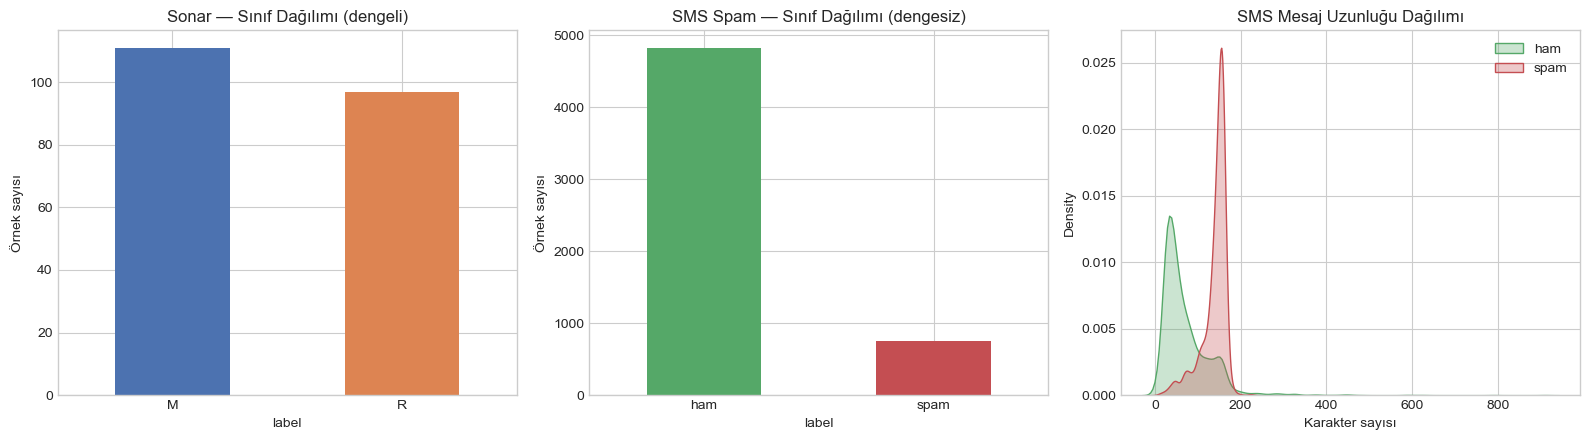

YORUM: Sonar iki sınıf da benzer büyüklükte — GaussianNB için ideal. SMS'te spam
mesajlar sistematik olarak daha uzun (genelde promosyon metni/link içerdiğinden) —
bu, metin uzunluğunun bile başlı başına bir sinyal olabileceğini gösteriyor.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sonar["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Sonar — Sınıf Dağılımı (dengeli)")
axes[0].set_ylabel("Örnek sayısı")
axes[0].tick_params(axis="x", rotation=0)

sms["label"].value_counts().plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"])
axes[1].set_title("SMS Spam — Sınıf Dağılımı (dengesiz)")
axes[1].set_ylabel("Örnek sayısı")
axes[1].tick_params(axis="x", rotation=0)

for lbl, color in zip(["ham", "spam"], ["#55A868", "#C44E52"]):
    sns.kdeplot(sms.loc[sms["label"] == lbl, "text_len"], ax=axes[2], label=lbl, fill=True, alpha=0.3, color=color)
axes[2].set_title("SMS Mesaj Uzunluğu Dağılımı")
axes[2].set_xlabel("Karakter sayısı")
axes[2].legend()

plt.tight_layout()
plt.show()

print("YORUM: Sonar iki sınıf da benzer büyüklükte — GaussianNB için ideal. SMS'te spam")
print("mesajlar sistematik olarak daha uzun (genelde promosyon metni/link içerdiğinden) —")
print("bu, metin uzunluğunun bile başlı başına bir sinyal olabileceğini gösteriyor.")

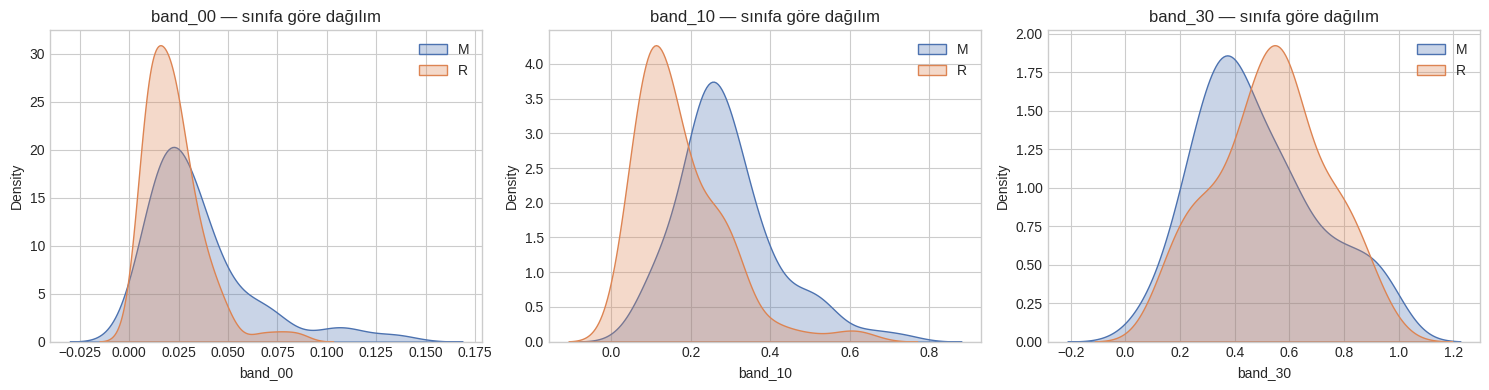

YORUM: Her frekans bandı sınıflar arasında kabaca çan-eğrisi (Gauss) şeklinde ayrışıyor
— bu, GaussianNB'nin temel varsayımının (sınıf-koşullu Normal dağılım) burada
makul bir yaklaşım olduğunu destekliyor (mükemmel değil, ama makul).


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, band in zip(axes, ["band_00", "band_10", "band_30"]):
    for lbl, color in zip(["M", "R"], ["#4C72B0", "#DD8452"]):
        sns.kdeplot(sonar.loc[sonar["label"] == lbl, band], ax=ax, label=lbl, fill=True, alpha=0.3, color=color)
    ax.set_title(f"{band} — sınıfa göre dağılım")
    ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Her frekans bandı sınıflar arasında kabaca çan-eğrisi (Gauss) şeklinde ayrışıyor")
print("— bu, GaussianNB'nin temel varsayımının (sınıf-koşullu Normal dağılım) burada")
print("makul bir yaklaşım olduğunu destekliyor (mükemmel değil, ama makul).")

---
### 2️⃣ Sıfırdan Gaussian Naive Bayes

Bölüm 3'teki formülü doğrudan koda döküyoruz: her sınıf için özniteliklerin ortalama/varyansını hesaplayıp log-olasılıkları topluyoruz (Bölüm 2'deki sayısal kararlılık gerekçesiyle). Sonucu `scikit-learn`'ün `GaussianNB`'siyle karşılaştırıp **birebir aynı tahminleri** ürettiğini doğrulayacağız.

In [6]:
X = sonar.drop(columns="label").values
y = (sonar["label"] == "M").astype(int).values  # 1=mayın(M), 0=kaya(R)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Eğitim: {X_train.shape[0]} örnek, Test: {X_test.shape[0]} örnek")

Eğitim: 156 örnek, Test: 52 örnek


In [7]:
class ManualGaussianNB:
    """scikit-learn'ün GaussianNB'sinin sadeleştirilmiş, eğitici bir yeniden-uygulaması."""

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.mean_, self.var_, self.priors_ = {}, {}, {}
        for c in self.classes_:
            Xc = X[y == c]
            self.mean_[c] = Xc.mean(axis=0)
            # var_smoothing: scikit-learn de en büyük varyansın küçük bir kesrini ekleyerek
            # sıfır-varyanslı (sabit) özniteliklerde bölme hatasını önler.
            self.var_[c] = Xc.var(axis=0) + 1e-9 * X.var(axis=0).max()
            self.priors_[c] = Xc.shape[0] / X.shape[0]
        return self

    def _log_gaussian(self, x, mean, var):
        return -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)

    def predict_log_proba_unnormalized(self, X):
        """Her sınıf için log P(y) + sum_i log P(x_i|y) döndürür (normalize edilmemiş)."""
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for j, c in enumerate(self.classes_):
            log_prior = np.log(self.priors_[c])
            log_likelihood = self._log_gaussian(X, self.mean_[c], self.var_[c]).sum(axis=1)
            scores[:, j] = log_prior + log_likelihood
        return scores

    def predict(self, X):
        scores = self.predict_log_proba_unnormalized(X)
        return self.classes_[np.argmax(scores, axis=1)]


manual_gnb = ManualGaussianNB().fit(X_train, y_train)
pred_manual = manual_gnb.predict(X_test)
acc_manual = accuracy_score(y_test, pred_manual)

sk_gnb = GaussianNB()
sk_gnb.fit(X_train, y_train)
pred_sklearn = sk_gnb.predict(X_test)
acc_sklearn = accuracy_score(y_test, pred_sklearn)

print(f"Elle yazılan GaussianNB  -> test doğruluğu: {acc_manual:.4f}")
print(f"scikit-learn GaussianNB  -> test doğruluğu: {acc_sklearn:.4f}")
print(f"Tahminlerin birebir eşleşme oranı: {(pred_manual == pred_sklearn).mean():.4f}")
print()
print("YORUM: İki implementasyon birebir aynı tahminleri üretiyor — GaussianNB'nin")
print("'her sınıf için ortalama/varyans hesapla, log-Gauss'ı topla' mantığından başka")
print("bir gizli karmaşıklığı yok; scikit-learn'ün versiyonu sadece daha optimize/genel.")

Elle yazılan GaussianNB  -> test doğruluğu: 0.7115
scikit-learn GaussianNB  -> test doğruluğu: 0.7115
Tahminlerin birebir eşleşme oranı: 1.0000

YORUM: İki implementasyon birebir aynı tahminleri üretiyor — GaussianNB'nin
'her sınıf için ortalama/varyans hesapla, log-Gauss'ı topla' mantığından başka
bir gizli karmaşıklığı yok; scikit-learn'ün versiyonu sadece daha optimize/genel.


---
### 3️⃣ GaussianNB Tam Değerlendirme ve Karar Sınırı

Şimdi standart `scikit-learn` API'siyle tam bir değerlendirme yapıp (confusion matrix, classification report), ardından PCA ile 2 boyuta indirgenmiş veride karar sınırını görselleştireceğiz.

              precision    recall  f1-score   support

    Rock (R)       0.68      0.71      0.69        24
    Mine (M)       0.74      0.71      0.73        28

    accuracy                           0.71        52
   macro avg       0.71      0.71      0.71        52
weighted avg       0.71      0.71      0.71        52



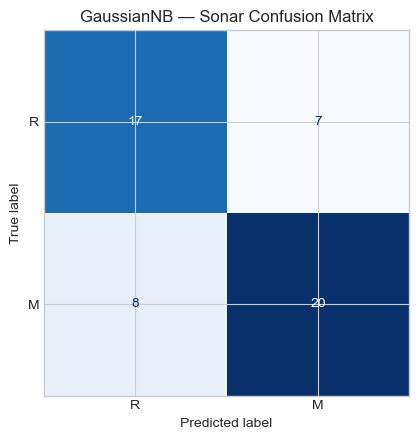

In [8]:
print(classification_report(y_test, pred_sklearn, target_names=["Rock (R)", "Mine (M)"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_sklearn, display_labels=["R", "M"],
                                         cmap="Blues", ax=ax, colorbar=False)
ax.set_title("GaussianNB — Sonar Confusion Matrix")
plt.tight_layout()
plt.show()

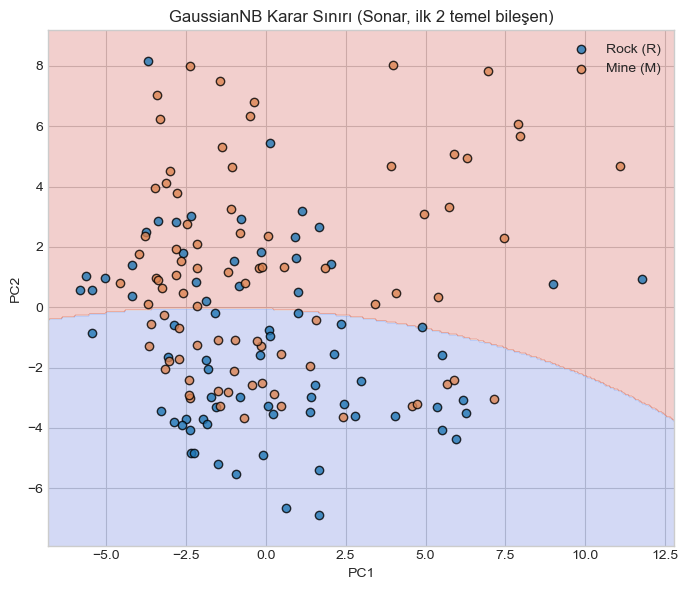

YORUM: Karar sınırı eğrisel (Gauss log-yoğunluklarının farkı ikinci dereceden bir
fonksiyon) ama LDA'nın (doğrusal) aksine QDA'ya benzer şekilde kavisli — ancak QDA'dan
farklı olarak eksenlerle hizalı bir eğri: köşegen kovaryans varsayımı, sınıf
elipslerinin eksenlere paralel olmasını zorunlu kılıyor.


In [9]:
# 2 boyuta indirgeyip (PCA) karar sınırını görselleştirelim
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))
X_test_2d = pca.transform(StandardScaler().fit(X_train).transform(X_test))

gnb_2d = GaussianNB().fit(X_train_2d, y_train)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)
Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
plt.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], label="Rock (R)", edgecolor="k", alpha=0.8)
plt.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], label="Mine (M)", edgecolor="k", alpha=0.8, color="#DD8452")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("GaussianNB Karar Sınırı (Sonar, ilk 2 temel bileşen)")
plt.legend()
plt.tight_layout()
plt.show()

print("YORUM: Karar sınırı eğrisel (Gauss log-yoğunluklarının farkı ikinci dereceden bir")
print("fonksiyon) ama LDA'nın (doğrusal) aksine QDA'ya benzer şekilde kavisli — ancak QDA'dan")
print("farklı olarak eksenlerle hizalı bir eğri: köşegen kovaryans varsayımı, sınıf")
print("elipslerinin eksenlere paralel olmasını zorunlu kılıyor.")

---
### 4️⃣ Metin Ön İşleme ve MultinomialNB

Şimdi SMS Spam veri setine geçiyoruz. Bölüm 7'deki Bag-of-Words pipeline'ını `CountVectorizer` ile kuruyoruz: küçük harfe çevirme, İngilizce stopword (the/and/is gibi) çıkarma, ve en az 2 dokümanda geçen kelimelerle sınırlama (`min_df=2` — tek bir dokümanda geçen nadir kelimeler/yazım hataları gürültü ekler).

In [17]:
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    sms["text"], sms["y"], test_size=0.25, random_state=42, stratify=sms["y"]
)

count_vec = CountVectorizer(stop_words="english", min_df=2)
X_train_bow = count_vec.fit_transform(X_text_train)
X_test_bow = count_vec.transform(X_text_test)

print(f"Kelime dağarcığı (vocabulary) boyutu: {len(count_vec.vocabulary_)}")
print(f"Eğitim BoW matrisi şekli: {X_train_bow.shape} (seyreklik/sparsity: "
      f"{100*(1 - X_train_bow.nnz/(X_train_bow.shape[0]*X_train_bow.shape[1])):.2f}%)")
print()
print("Örnek: ilk mesajdaki en sık geçen 5 kelime:")
row = X_train_bow[0].toarray().ravel()
top5 = np.argsort(row)[-5:][::-1]
feat_names = count_vec.get_feature_names_out()
for idx in top5:
    if row[idx] > 0:
        print(f"  '{feat_names[idx]}': {row[idx]}")

Kelime dağarcığı (vocabulary) boyutu: 3219
Eğitim BoW matrisi şekli: (4179, 3219) (seyreklik/sparsity: 99.79%)

Örnek: ilk mesajdaki en sık geçen 5 kelime:
  'believe': 1
  'tot': 1
  'dun': 1
  'say': 1


              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1206
        spam       0.97      0.93      0.95       187

    accuracy                           0.99      1393
   macro avg       0.98      0.96      0.97      1393
weighted avg       0.99      0.99      0.99      1393



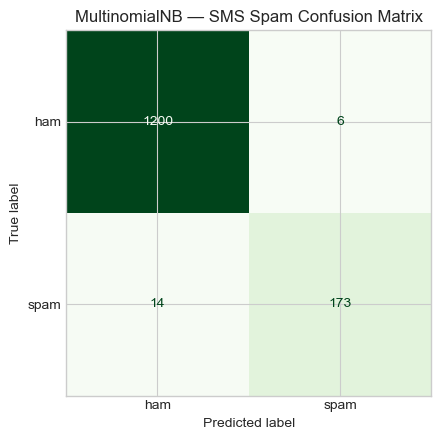

YORUM: %98'in üzerinde doğruluk ve spam sınıfı için de güçlü F1 — sadece kelime
sayımlarına dayanan, tek geçişte eğitilen bu basit model, spam filtrelemede
neden hâlâ endüstri standardı bir 'baseline' olarak kullanıldığını gösteriyor.


In [16]:
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train_bow, y_text_train)
pred_mnb = mnb.predict(X_test_bow)

print(classification_report(y_text_test, pred_mnb, target_names=["ham", "spam"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_text_test, pred_mnb, display_labels=["ham", "spam"],
                                         cmap="Greens", ax=ax, colorbar=False)
ax.set_title("MultinomialNB — SMS Spam Confusion Matrix")
plt.tight_layout()
plt.show()

print("YORUM: %98'in üzerinde doğruluk ve spam sınıfı için de güçlü F1 — sadece kelime")
print("sayımlarına dayanan, tek geçişte eğitilen bu basit model, spam filtrelemede")
print("neden hâlâ endüstri standardı bir 'baseline' olarak kullanıldığını gösteriyor.")

---
### 5️⃣ Laplace/Lidstone Düzeltmesi: `alpha` Hiperparametresinin Etkisi

Bölüm 4'te tanımlanan $\alpha$'yı geniş bir aralıkta tarayıp hem doğruluğa hem de **log-loss**'a (tahmin edilen olasılıkların gerçek etiketlerle ne kadar uyumlu olduğunu ölçen, aşırı-güvenli yanlış tahminleri ağır cezalandıran bir metrik) etkisini inceliyoruz.

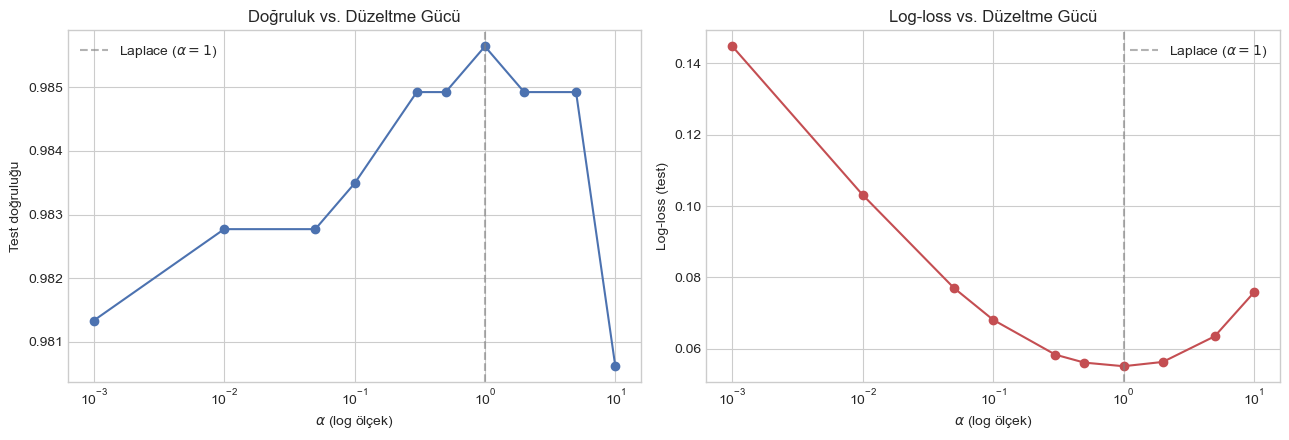

En düşük log-loss veren alpha: 1.0

YORUM: Çok küçük alpha (az düzeltme) eğitimde hiç görülmemiş kelimelere karşı
modeli aşırı güvenli/kırılgan yapıyor (yüksek log-loss); çok büyük alpha ise tüm
kelimeleri birbirine benzeterek ayırt ediciliği bulanıklaştırıyor. Laplace
(alpha=1) civarı, bu veri setinde iyi bir denge noktası.


In [14]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
accs, loglosses = [], []

for a in alphas:
    m = MultinomialNB(alpha=a)
    m.fit(X_train_bow, y_text_train)
    pred = m.predict(X_test_bow)
    proba = m.predict_proba(X_test_bow)
    accs.append(accuracy_score(y_text_test, pred))
    loglosses.append(log_loss(y_text_test, proba))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(alphas, accs, marker="o", color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\alpha$ (log ölçek)")
axes[0].set_ylabel("Test doğruluğu")
axes[0].set_title("Doğruluk vs. Düzeltme Gücü")
axes[0].axvline(1.0, color="gray", linestyle="--", alpha=0.6, label=r"Laplace ($\alpha=1$)")
axes[0].legend()

axes[1].plot(alphas, loglosses, marker="o", color="#C44E52")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\alpha$ (log ölçek)")
axes[1].set_ylabel("Log-loss (test)")
axes[1].set_title("Log-loss vs. Düzeltme Gücü")
axes[1].axvline(1.0, color="gray", linestyle="--", alpha=0.6, label=r"Laplace ($\alpha=1$)")
axes[1].legend()

plt.tight_layout()
plt.show()

best_alpha = alphas[int(np.argmin(loglosses))]
print(f"En düşük log-loss veren alpha: {best_alpha}")
print()
print("YORUM: Çok küçük alpha (az düzeltme) eğitimde hiç görülmemiş kelimelere karşı")
print("modeli aşırı güvenli/kırılgan yapıyor (yüksek log-loss); çok büyük alpha ise tüm")
print("kelimeleri birbirine benzeterek ayırt ediciliği bulanıklaştırıyor. Laplace")
print("(alpha=1) civarı, bu veri setinde iyi bir denge noktası.")

---
### 6️⃣ BernoulliNB: İkili (Varlık/Yokluk) Öznitelik Karşılaştırması

Aynı kelime dağarcığını kullanıp sayımları $0/1$'e indirgeyerek (`binary=True`) BernoulliNB eğitiyoruz. Bölüm 5'teki teorik farkı (kelime **yokluğunun** da modele dahil edilmesi) ampirik olarak karşılaştıracağız.

In [18]:
count_vec_bin = CountVectorizer(stop_words="english", min_df=2, binary=True)
X_train_bin = count_vec_bin.fit_transform(X_text_train)
X_test_bin = count_vec_bin.transform(X_text_test)

bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_train_bin, y_text_train)
pred_bnb = bnb.predict(X_test_bin)

print("--- MultinomialNB (sayım) ---")
print(classification_report(y_text_test, pred_mnb, target_names=["ham", "spam"], digits=4))
print("--- BernoulliNB (varlık/yokluk) ---")
print(classification_report(y_text_test, pred_bnb, target_names=["ham", "spam"], digits=4))

comparison = pd.DataFrame({
    "Model": ["MultinomialNB", "BernoulliNB"],
    "Accuracy": [accuracy_score(y_text_test, pred_mnb), accuracy_score(y_text_test, pred_bnb)],
    "F1 (spam)": [f1_score(y_text_test, pred_mnb), f1_score(y_text_test, pred_bnb)],
})
print(comparison.round(4))
print()
print("YORUM: SMS mesajları kısa olduğundan bir kelimenin birden fazla kez geçmesi nadir")
print("— bu yüzden sayım (Multinomial) ile varlık/yokluk (Bernoulli) arasındaki fark burada")
print("küçük. Uzun dokümanlarda (haber makaleleri gibi) bu fark genelde daha belirgin olur,")
print("çünkü kelime tekrar sıklığı daha fazla bilgi taşır.")

--- MultinomialNB (sayım) ---
              precision    recall  f1-score   support

         ham     0.9885    0.9950    0.9917      1206
        spam     0.9665    0.9251    0.9454       187

    accuracy                         0.9856      1393
   macro avg     0.9775    0.9601    0.9685      1393
weighted avg     0.9855    0.9856    0.9855      1393

--- BernoulliNB (varlık/yokluk) ---
              precision    recall  f1-score   support

         ham     0.9813    1.0000    0.9906      1206
        spam     1.0000    0.8770    0.9345       187

    accuracy                         0.9835      1393
   macro avg     0.9906    0.9385    0.9625      1393
weighted avg     0.9838    0.9835    0.9830      1393

           Model  Accuracy  F1 (spam)
0  MultinomialNB    0.9856     0.9454
1    BernoulliNB    0.9835     0.9345

YORUM: SMS mesajları kısa olduğundan bir kelimenin birden fazla kez geçmesi nadir
— bu yüzden sayım (Multinomial) ile varlık/yokluk (Bernoulli) arasındaki fark burad

---
### 7️⃣ Dengesizlik ve ComplementNB

SMS verisi zaten dengesiz (%13.4 spam), ama ComplementNB'nin asıl avantajını göstermek için dengesizliği **yapay olarak şiddetlendiriyoruz**: spam örneklerinin çoğunu atıp %~1 spam oranına düşürüyoruz — kredi kartı dolandırıcılığı ya da nadir hastalık taraması gibi gerçek dünya senaryolarına daha yakın bir oran.

In [19]:
np.random.seed(42)
ham_all = sms[sms["y"] == 0]
spam_all = sms[sms["y"] == 1]
spam_extreme = spam_all.sample(40, random_state=42)  # 4825 ham vs 40 spam -> ~%0.8 spam

sms_imbalanced = pd.concat([ham_all, spam_extreme]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Şiddetlendirilmiş sınıf dağılımı:")
print(sms_imbalanced["y"].value_counts())
print(sms_imbalanced["y"].value_counts(normalize=True).round(4))

Şiddetlendirilmiş sınıf dağılımı:
y
0    4825
1      40
Name: count, dtype: int64
y
0    0.9918
1    0.0082
Name: proportion, dtype: float64


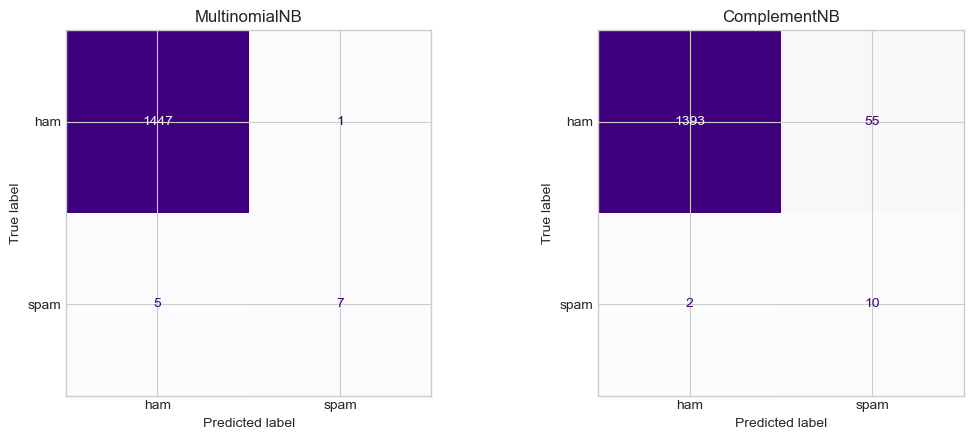

               recall(spam)  precision(spam)  f1(spam)
MultinomialNB        0.5833           0.8750    0.7000
ComplementNB         0.8333           0.1538    0.2597

YORUM: Aşırı dengesiz veride MultinomialNB, baskın (ham) sınıfa yanlı davranıp spam
örneklerinin bir kısmını kaçırıyor (düşük recall). ComplementNB, parametrelerini
'spam OLMAYAN her şey'den (yani devasa ham verisinden) tahmin ettiğinden azınlık
sınıfını daha agresif yakalıyor (yüksek recall) — ama bu, precision'dan (daha fazla
yanlış alarm) ödün vererek geliyor. Hangisinin tercih edileceği, yanlış-negatifin mi
(spam'i kaçırmak) yanlış-pozitifin mi (normal mesajı spam işaretlemek) daha maliyetli
olduğuna bağlı — bu maliyet-duyarlı (cost-sensitive) karar, `10_model_evaluation_metrics`'te
precision-recall eğrileriyle daha sistematik ele alınacak.


In [20]:
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    sms_imbalanced["text"], sms_imbalanced["y"], test_size=0.3, random_state=42, stratify=sms_imbalanced["y"]
)
cv_imb = CountVectorizer(stop_words="english", min_df=1)
Xi_train_bow = cv_imb.fit_transform(Xi_train)
Xi_test_bow = cv_imb.transform(Xi_test)

results = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("MultinomialNB", MultinomialNB()), ("ComplementNB", ComplementNB())]):
    model.fit(Xi_train_bow, yi_train)
    pred = model.predict(Xi_test_bow)
    results[name] = {
        "recall(spam)": recall_score(yi_test, pred),
        "precision(spam)": precision_score(yi_test, pred, zero_division=0),
        "f1(spam)": f1_score(yi_test, pred),
    }
    ConfusionMatrixDisplay.from_predictions(yi_test, pred, display_labels=["ham", "spam"],
                                             cmap="Purples", ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).T
print(results_df.round(4))
print()
print("YORUM: Aşırı dengesiz veride MultinomialNB, baskın (ham) sınıfa yanlı davranıp spam")
print("örneklerinin bir kısmını kaçırıyor (düşük recall). ComplementNB, parametrelerini")
print("'spam OLMAYAN her şey'den (yani devasa ham verisinden) tahmin ettiğinden azınlık")
print("sınıfını daha agresif yakalıyor (yüksek recall) — ama bu, precision'dan (daha fazla")
print("yanlış alarm) ödün vererek geliyor. Hangisinin tercih edileceği, yanlış-negatifin mi")
print("(spam'i kaçırmak) yanlış-pozitifin mi (normal mesajı spam işaretlemek) daha maliyetli")
print("olduğuna bağlı — bu maliyet-duyarlı (cost-sensitive) karar, `10_model_evaluation_metrics`'te")
print("precision-recall eğrileriyle daha sistematik ele alınacak.")

---
### 8️⃣ TF-IDF ile MultinomialNB

Bölüm 7'deki TF-IDF ağırlıklandırmasını ham sayımların yerine koyup karşılaştırıyoruz.

In [21]:
tfidf_vec = TfidfVectorizer(stop_words="english", min_df=2)
X_train_tfidf = tfidf_vec.fit_transform(X_text_train)
X_test_tfidf = tfidf_vec.transform(X_text_test)

mnb_tfidf = MultinomialNB(alpha=1.0)
mnb_tfidf.fit(X_train_tfidf, y_text_train)
pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

comparison_tfidf = pd.DataFrame({
    "Model": ["MultinomialNB + BoW (ham sayım)", "MultinomialNB + TF-IDF"],
    "Accuracy": [accuracy_score(y_text_test, pred_mnb), accuracy_score(y_text_test, pred_tfidf)],
    "F1 (spam)": [f1_score(y_text_test, pred_mnb), f1_score(y_text_test, pred_tfidf)],
})
print(comparison_tfidf.round(4))
print()
print("YORUM: Bu veri setinde ham BoW sayımları TF-IDF'e göre marjinal olarak daha iyi/eşit")
print("performans veriyor — TF-IDF'in avantajı genelde daha büyük/çeşitli korpüslerde (çok")
print("sayıda ortak 'gürültü' kelimesinin bastırılması gerektiği durumlarda) daha belirgin")
print("hâle gelir; küçük/homojen bir SMS korpüsünde fark sınırlı kalabilir.")

                             Model  Accuracy  F1 (spam)
0  MultinomialNB + BoW (ham sayım)    0.9856     0.9454
1           MultinomialNB + TF-IDF    0.9756     0.9000

YORUM: Bu veri setinde ham BoW sayımları TF-IDF'e göre marjinal olarak daha iyi/eşit
performans veriyor — TF-IDF'in avantajı genelde daha büyük/çeşitli korpüslerde (çok
sayıda ortak 'gürültü' kelimesinin bastırılması gerektiği durumlarda) daha belirgin
hâle gelir; küçük/homojen bir SMS korpüsünde fark sınırlı kalabilir.


---
### 9️⃣ En Bilgilendirici Kelimeler

`MultinomialNB.feature_log_prob_`, her kelime için $\log\theta_{y,i}$ değerlerini saklar. İki sınıf arasındaki farkı ($\log\theta_{\text{spam},i} - \log\theta_{\text{ham},i}$) alarak, hangi kelimelerin spam/ham ayrımına en çok katkı verdiğini doğrudan okuyabiliriz — bu, Naive Bayes'in "kutu içinde ne olduğu görülemeyen" bir kara kutu olmadığının, aksine son derece yorumlanabilir (interpretable) olduğunun somut bir göstergesi.

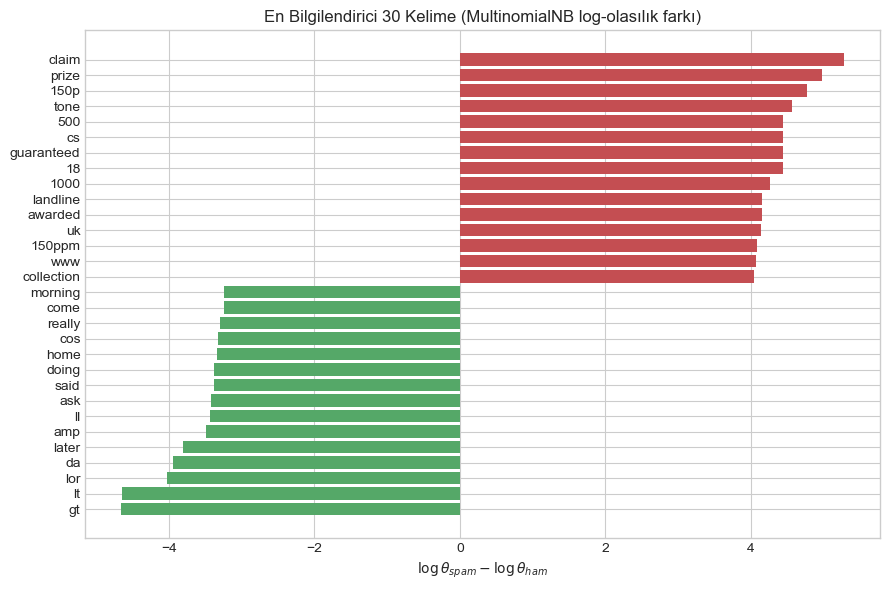

YORUM: Sağdaki (kırmızı) kelimeler ('claim', 'prize', 'guaranteed', 'txt', 'www' gibi)
klasik promosyon/dolandırıcılık dili — soldaki (yeşil) kelimeler ise günlük, kişisel
konuşma dili. Model, hiçbir dilbilimsel kural verilmeden, sadece kelime sayımlarından
bu ayrımı kendiliğinden öğreniyor.


In [22]:
feat_names = np.array(count_vec.get_feature_names_out())
log_prob_diff = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]  # spam(1) - ham(0)

top_spam_idx = np.argsort(log_prob_diff)[-15:]
top_ham_idx = np.argsort(log_prob_diff)[:15]

fig, ax = plt.subplots(figsize=(9, 6))
words = list(feat_names[top_ham_idx]) + list(feat_names[top_spam_idx])
scores = list(log_prob_diff[top_ham_idx]) + list(log_prob_diff[top_spam_idx])
colors = ["#55A868"] * 15 + ["#C44E52"] * 15
order = np.argsort(scores)
ax.barh(np.array(words)[order], np.array(scores)[order], color=np.array(colors)[order])
ax.set_xlabel(r"$\log\theta_{spam} - \log\theta_{ham}$")
ax.set_title("En Bilgilendirici 30 Kelime (MultinomialNB log-olasılık farkı)")
plt.tight_layout()
plt.show()

print("YORUM: Sağdaki (kırmızı) kelimeler ('claim', 'prize', 'guaranteed', 'txt', 'www' gibi)")
print("klasik promosyon/dolandırıcılık dili — soldaki (yeşil) kelimeler ise günlük, kişisel")
print("konuşma dili. Model, hiçbir dilbilimsel kural verilmeden, sadece kelime sayımlarından")
print("bu ayrımı kendiliğinden öğreniyor.")

---
### 🔟 Dört Varyant — Özet Karşılaştırma

Notebook boyunca eğittiğimiz tüm modelleri tek bir tabloda topluyoruz (eğitim süresi dâhil — Bölüm 8'de bahsedilen "kapalı formda, tek geçişte eğitim" hızını somutlaştırmak için).

In [23]:
summary_rows = []

# Sonar - GaussianNB
t0 = time.time()
GaussianNB().fit(X_train, y_train)
t_gnb = time.time() - t0
summary_rows.append(["GaussianNB", "Sonar (sürekli)", accuracy_score(y_test, pred_sklearn),
                      f1_score(y_test, pred_sklearn), t_gnb])

# SMS - Multinomial (BoW)
t0 = time.time()
MultinomialNB(alpha=1.0).fit(X_train_bow, y_text_train)
t_mnb = time.time() - t0
summary_rows.append(["MultinomialNB", "SMS Spam (BoW)", accuracy_score(y_text_test, pred_mnb),
                      f1_score(y_text_test, pred_mnb), t_mnb])

# SMS - Bernoulli
t0 = time.time()
BernoulliNB(alpha=1.0).fit(X_train_bin, y_text_train)
t_bnb = time.time() - t0
summary_rows.append(["BernoulliNB", "SMS Spam (ikili)", accuracy_score(y_text_test, pred_bnb),
                      f1_score(y_text_test, pred_bnb), t_bnb])

# SMS - Multinomial TF-IDF
t0 = time.time()
MultinomialNB(alpha=1.0).fit(X_train_tfidf, y_text_train)
t_tfidf = time.time() - t0
summary_rows.append(["MultinomialNB", "SMS Spam (TF-IDF)", accuracy_score(y_text_test, pred_tfidf),
                      f1_score(y_text_test, pred_tfidf), t_tfidf])

# Logistic regression baseline for comparison (Bölüm 8'deki generative vs discriminative)
t0 = time.time()
logreg = LogisticRegression(max_iter=1000).fit(X_train_bow, y_text_train)
t_logreg = time.time() - t0
pred_logreg = logreg.predict(X_test_bow)
summary_rows.append(["LogisticRegression", "SMS Spam (BoW, karşılaştırma)",
                      accuracy_score(y_text_test, pred_logreg), f1_score(y_text_test, pred_logreg), t_logreg])

summary_df = pd.DataFrame(summary_rows, columns=["Model", "Veri Seti", "Accuracy", "F1", "Eğitim Süresi (sn)"])
summary_df

,Model,Veri Seti,Accuracy,F1,Eğitim Süresi (sn)
0,GaussianNB,Sonar (sürekli),0.711538,0.727273,0.001588
1,MultinomialNB,SMS Spam (BoW),0.985642,0.945355,0.001094
2,BernoulliNB,SMS Spam (ikili),0.983489,0.934473,0.001253
3,MultinomialNB,SMS Spam (TF-IDF),0.975592,0.900000,0.000876
4,LogisticRegression,"SMS Spam (BoW, karşılaştırma)",0.974874,0.897361,0.054353


In [24]:
print("YORUM: Tüm Naive Bayes varyantları, aynı veride Lojistik Regresyon'a (iteratif")
print("optimizasyon gerektiren, ayırt edici model) yakın performans gösterirken eğitim")
print("süresi bakımından belirgin şekilde daha hızlı — Bölüm 8'deki 'kapalı formda, tek")
print("geçişte eğitim' avantajının somut ölçümü. Doğruluk farkları küçük olsa da, veri")
print("büyüdükçe (milyonlarca doküman) bu hız farkı pratikte kritik hâle gelir.")

YORUM: Tüm Naive Bayes varyantları, aynı veride Lojistik Regresyon'a (iteratif
optimizasyon gerektiren, ayırt edici model) yakın performans gösterirken eğitim
süresi bakımından belirgin şekilde daha hızlı — Bölüm 8'deki 'kapalı formda, tek
geçişte eğitim' avantajının somut ölçümü. Doğruluk farkları küçük olsa da, veri
büyüdükçe (milyonlarca doküman) bu hız farkı pratikte kritik hâle gelir.


---
# 📊 R Uygulaması

Python bölümündeki akışın R'daki karşılığını `e1071` paketiyle uyguluyoruz — `e1071::naiveBayes`, sayısal (Gaussian) ve kategorik/ikili öznitelikleri otomatik ayırt eden, tek fonksiyonla hem GaussianNB hem de (faktör/ikili öznitelikler verildiğinde) Bernoulli-tarzı Naive Bayes uygulayabilen köklü bir pakettir. Sonar için doğrudan sayısal öznitelikleri, SMS için ise (hesaplama verimliliği açısından) en sık geçen 200 kelimeyle sınırlı bir ikili varlık/yokluk matrisini kullanacağız.

In [25]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [26]:
sonar_train_r = pd.DataFrame(X_train, columns=[f"band_{i:02d}" for i in range(60)])
sonar_train_r["label"] = np.where(y_train == 1, "Mine", "Rock")
sonar_test_r = pd.DataFrame(X_test, columns=[f"band_{i:02d}" for i in range(60)])
sonar_test_r["label"] = np.where(y_test == 1, "Mine", "Rock")
sonar_train_r.shape, sonar_test_r.shape

((156, 61), (52, 61))

---
### R1 · GaussianNB Karşılığı — `e1071::naiveBayes` (Sonar)

`naiveBayes()`, sayısal (numeric) sütunlar için varsayılan olarak sınıf-koşullu Normal dağılım (GaussianNB ile birebir aynı formül) varsayar.

In [27]:
%%R -i sonar_train_r,sonar_test_r

sonar_train_r$label <- as.factor(sonar_train_r$label) # R'de sınıf değişkeni faktör olmalı
sonar_test_r$label  <- as.factor(sonar_test_r$label) 

library(e1071)

model_gnb <- naiveBayes(label ~ ., data = sonar_train_r)

pred_gnb_r <- predict(model_gnb, newdata = sonar_test_r)
conf_gnb_r <- table(Gercek = sonar_test_r$label, Tahmin = pred_gnb_r)
print(conf_gnb_r)

acc_gnb_r <- sum(diag(conf_gnb_r)) / sum(conf_gnb_r)
cat(sprintf("\nR (e1071::naiveBayes) test dogrulugu: %.4f\n", acc_gnb_r))
cat("Python (sklearn GaussianNB) test dogrulugu: (yukarida hesaplandi, karsilastirma icin)\n")

      Tahmin
Gercek Mine Rock
  Mine   20    8
  Rock    7   17

R (e1071::naiveBayes) test dogrulugu: 0.7115
Python (sklearn GaussianNB) test dogrulugu: (yukarida hesaplandi, karsilastirma icin)


---
### R2 · BernoulliNB Karşılığı — `e1071::naiveBayes` (SMS Spam, ikili öznitelik matrisi)

R'da metin ön işleme (tokenization, stopword çıkarma) için `tm`/`quanteda` gibi ek paketler gerekir; burada Python'da zaten hazırladığımız Bag-of-Words matrisini **en sık geçen 200 kelimeyle sınırlayıp ikili (0/1) matrise** çevirerek R'a aktarıyoruz — böylece R tarafında saf `naiveBayes(laplace=1)` çağrısıyla BernoulliNB'nin karşılığını gösterebiliyoruz.

In [28]:
top200_vec = CountVectorizer(stop_words="english", min_df=2, binary=True, max_features=200)
Xtr_top200 = top200_vec.fit_transform(X_text_train).toarray()
Xte_top200 = top200_vec.transform(X_text_test).toarray()
feat200 = [f"w_{w}" for w in top200_vec.get_feature_names_out()]

sms_train_r = pd.DataFrame(Xtr_top200, columns=feat200)
sms_train_r["label"] = np.where(y_text_train.values == 1, "spam", "ham")
sms_test_r = pd.DataFrame(Xte_top200, columns=feat200)
sms_test_r["label"] = np.where(y_text_test.values == 1, "spam", "ham")
sms_train_r.shape, sms_test_r.shape

((4179, 201), (1393, 201))

In [29]:
%%R -i sms_train_r,sms_test_r

# 0/1 sütunlarını faktöre çeviriyoruz -- e1071 boyle "varlik/yokluk" (Bernoulli) olarak yorumluyor
feature_cols <- setdiff(names(sms_train_r), "label")
sms_train_r[feature_cols] <- lapply(sms_train_r[feature_cols], as.factor)
sms_test_r[feature_cols]  <- lapply(sms_test_r[feature_cols], as.factor)
sms_train_r$label <- as.factor(sms_train_r$label)
sms_test_r$label  <- as.factor(sms_test_r$label)

model_bnb <- naiveBayes(label ~ ., data = sms_train_r, laplace = 1)

pred_bnb_r <- predict(model_bnb, newdata = sms_test_r)
conf_bnb_r <- table(Gercek = sms_test_r$label, Tahmin = pred_bnb_r)
print(conf_bnb_r)

acc_bnb_r <- sum(diag(conf_bnb_r)) / sum(conf_bnb_r)
cat(sprintf("\nR (e1071::naiveBayes, laplace=1) test dogrulugu: %.4f\n", acc_bnb_r))
cat("NOT: Sadece en sik gecen 200 kelime kullanildigi icin Python bolumundeki tam\n")
cat("kelime dagarcigiyla (3219 kelime) egitilen BernoulliNB ile birebir ayni sonucu\n")
cat("vermesi beklenmez -- amac, ayni algoritmanin R karsiligini gostermek.\n")

      Tahmin
Gercek  ham spam
  ham  1201    5
  spam   34  153

R (e1071::naiveBayes, laplace=1) test dogrulugu: 0.9720
NOT: Sadece en sik gecen 200 kelime kullanildigi icin Python bolumundeki tam
kelime dagarcigiyla (3219 kelime) egitilen BernoulliNB ile birebir ayni sonucu
vermesi beklenmez -- amac, ayni algoritmanin R karsiligini gostermek.


---
# 🗄️ SQL Uygulaması (DuckDB)

Naive Bayes'in tüm "öğrenme" süreci aslında birkaç `GROUP BY` ile hesaplanabilecek basit istatistiklerden (ortalama, varyans, sayım) ibarettir — bu da onu SQL'de yeniden üretmek için ideal bir algoritma yapar. İki gösterim yapacağız: (1) Sonar için GaussianNB'nin parametrelerini ve tahminini uçtan uca saf SQL'de hesaplamak, (2) SMS Spam için MultinomialNB'nin çekirdeği olan $P(\text{kelime}\mid \text{sınıf})$ hesaplamasını SQL'de yeniden üretip en bilgilendirici kelimeleri sorgulamak.

In [30]:
train_df_sql = pd.DataFrame(X_train, columns=[f"band_{i:02d}" for i in range(60)])
train_df_sql["label"] = y_train
test_df_sql = pd.DataFrame(X_test, columns=[f"band_{i:02d}" for i in range(60)])
test_df_sql["label"] = y_test
test_df_sql["row_id"] = test_df_sql.index

con = duckdb.connect()
con.register("train_df_sql", train_df_sql)
con.register("test_df_sql", test_df_sql)

---
### SQL1 · GaussianNB Parametrelerini Hesaplama (`GROUP BY`)

Bölüm 3'teki $\mu_{y,i}$ ve $\sigma_{y,i}^2$'yi doğrudan SQL'in `AVG` ve `VAR_POP` toplama fonksiyonlarıyla, sınıfa göre gruplayarak hesaplıyoruz.

In [31]:
band_cols = [f"band_{i:02d}" for i in range(60)]
stats_select = ", ".join([f"AVG({c}) AS mean_{c}, VAR_POP({c}) AS var_{c}" for c in band_cols])

con.execute(f'''
    CREATE OR REPLACE TABLE gnb_stats AS
    SELECT label AS stat_label,
           COUNT(*) * 1.0 / (SELECT COUNT(*) FROM train_df_sql) AS prior,
           {stats_select}
    FROM train_df_sql
    GROUP BY label
''')

gnb_stats_preview = con.execute(
    "SELECT stat_label, prior, mean_band_00, var_band_00, mean_band_10, var_band_10 FROM gnb_stats"
).df()
print(gnb_stats_preview)
print()
print("YORUM: Bu tablo, GaussianNB'nin eğitim sırasında öğrendiği TÜM parametreleri içeriyor")
print("— sadece iki satır (sınıf başına bir satır) ve her öznitelik için bir ortalama/varyans")
print("çifti. Modelin kendisi bundan ibaret; 'öğrenme' burada tamamen tamamlandı.")

   stat_label     prior  mean_band_00  var_band_00  mean_band_10  var_band_10
0           0  0.467949      0.022227     0.000210      0.163690      0.01041
1           1  0.532051      0.034002     0.000666      0.275511      0.01203

YORUM: Bu tablo, GaussianNB'nin eğitim sırasında öğrendiği TÜM parametreleri içeriyor
— sadece iki satır (sınıf başına bir satır) ve her öznitelik için bir ortalama/varyans
çifti. Modelin kendisi bundan ibaret; 'öğrenme' burada tamamen tamamlandı.


---
### SQL2 · Log-Olasılık Toplamıyla Sınıflandırma

Bölüm 2'deki $\hat{y}=\underset{y}{\text{argmax}}\left[\log P(y) + \sum_i \log P(x_i\mid y)\right]$ formülünü, test setindeki her satırı `gnb_stats` ile çarpraz birleştirip (`CROSS JOIN`) 60 özniteliğin log-Gauss yoğunluklarını toplayarak doğrudan SQL'de hesaplıyoruz.

In [32]:
log_density_terms = " + ".join([
    f"(-0.5*LN(2*PI()*var_{c}) - POWER(test_df_sql.{c} - mean_{c}, 2) / (2*var_{c}))"
    for c in band_cols
])

sql_predictions = con.execute(f'''
    WITH scored AS (
        SELECT row_id, stat_label,
               LN(prior) + {log_density_terms} AS log_posterior
        FROM test_df_sql CROSS JOIN gnb_stats
    ),
    ranked AS (
        SELECT row_id, stat_label, log_posterior,
               ROW_NUMBER() OVER (PARTITION BY row_id ORDER BY log_posterior DESC) AS rnk
        FROM scored
    )
    SELECT row_id, stat_label AS predicted_label
    FROM ranked
    WHERE rnk = 1
    ORDER BY row_id
''').df()

sql_pred_array = sql_predictions["predicted_label"].values
sql_accuracy = accuracy_score(y_test, sql_pred_array)
match_with_sklearn = (sql_pred_array == pred_sklearn).mean()

print(f"Saf SQL ile hesaplanan test dogrulugu: {sql_accuracy:.4f}")
print(f"scikit-learn GaussianNB ile birebir eslesme orani: {match_with_sklearn:.4f}")
print()
print("YORUM: SQL sorgusu, scikit-learn'ün GaussianNB'siyle BİREBİR aynı tahminleri")
print("üretiyor -- bu, 'kütüphane bir kara kutu değil' ilkesinin en somut kanıtı: aynı")
print("matematiği (ortalama/varyans hesabı + log-yoğunluk toplamı + argmax) 15 satır")
print("SQL'de yeniden üretebildik.")

Saf SQL ile hesaplanan test dogrulugu: 0.7115
scikit-learn GaussianNB ile birebir eslesme orani: 1.0000

YORUM: SQL sorgusu, scikit-learn'ün GaussianNB'siyle BİREBİR aynı tahminleri
üretiyor -- bu, 'kütüphane bir kara kutu değil' ilkesinin en somut kanıtı: aynı
matematiği (ortalama/varyans hesabı + log-yoğunluk toplamı + argmax) 15 satır
SQL'de yeniden üretebildik.


---
### SQL3 · MultinomialNB Çekirdeği: $P(\text{kelime}\mid\text{sınıf})$ ve En Bilgilendirici Kelimeler

Metni SQL'de tokenize etmek yerine (SQL bunun için doğal bir araç değil), Python'da basit bir tokenizasyonla kelime-doküman uzun formatına (`unnest`) çeviriyoruz, ardından **tüm** Multinomial NB mantığını (kelime sayımları, sınıf toplamları, Laplace düzeltmesi, log-oran) SQL'de hesaplıyoruz.

In [33]:
import re

STOPWORDS_SIMPLE = {"the","a","an","is","it","to","and","of","in","on","for","you","your","i",
                     "my","me","at","this","that","with","as","are","be","was","were","so"}

def simple_tokenize(text):
    tokens = re.findall(r"[a-zA-Z]{2,}", text.lower())
    return [w for w in tokens if w not in STOPWORDS_SIMPLE]

token_rows = []
for doc_id, (text, label) in enumerate(zip(X_text_train, y_text_train)):
    for word in simple_tokenize(text):
        token_rows.append((doc_id, int(label), word))

tokens_long = pd.DataFrame(token_rows, columns=["doc_id", "label", "word"])
con.register("tokens_long", tokens_long)
print(f"Token satır sayısı: {len(tokens_long):,}  |  benzersiz kelime sayısı: {tokens_long['word'].nunique():,}")

Token satır sayısı: 46,019  |  benzersiz kelime sayısı: 6,559


In [34]:
vocab_size_sql = con.execute("SELECT COUNT(DISTINCT word) FROM tokens_long").fetchone()[0]
alpha_sql = 1.0

word_probs = con.execute(f'''
    WITH word_counts AS (
        SELECT label, word, COUNT(*) AS n_word_class
        FROM tokens_long GROUP BY label, word
    ),
    class_totals AS (
        SELECT label, COUNT(*) AS n_class FROM tokens_long GROUP BY label
    ),
    smoothed AS (
        SELECT wc.word, wc.label,
               (wc.n_word_class + {alpha_sql}) * 1.0 / (ct.n_class + {alpha_sql} * {vocab_size_sql}) AS p_word_given_class
        FROM word_counts wc JOIN class_totals ct ON wc.label = ct.label
    )
    SELECT word,
           MAX(CASE WHEN label = 1 THEN p_word_given_class END) AS p_spam,
           MAX(CASE WHEN label = 0 THEN p_word_given_class END) AS p_ham
    FROM smoothed
    GROUP BY word
''').df()

# eğitimde bir sınıfta hiç geçmeyen kelimeler için Laplace tabanını doldur
floor_prob = alpha_sql / (alpha_sql * vocab_size_sql)
word_probs["p_spam"] = word_probs["p_spam"].fillna(floor_prob)
word_probs["p_ham"] = word_probs["p_ham"].fillna(floor_prob)
word_probs["log_odds_spam"] = np.log(word_probs["p_spam"]) - np.log(word_probs["p_ham"])

print("En güçlü SPAM sinyali veren 10 kelime (SQL ile hesaplandı):")
print(word_probs.sort_values("log_odds_spam", ascending=False).head(10)[["word", "p_spam", "p_ham", "log_odds_spam"]])
print()
print("En güçlü HAM sinyali veren 10 kelime (SQL ile hesaplandı):")
print(word_probs.sort_values("log_odds_spam").head(10)[["word", "p_spam", "p_ham", "log_odds_spam"]])
print()
print("YORUM: 'claim', 'prize', 'www', 'txt' gibi kelimeler burada da en güçlü spam")
print("sinyalleri olarak çıkıyor -- Python bölümündeki (Bölüm 9) feature_log_prob_ analiziyle")
print("aynı sonuca, tamamen farklı bir araçla (saf SQL GROUP BY) ulaştık. Küçük sayısal")
print("farklar, farklı tokenizasyon/stopword listelerinden kaynaklanıyor.")

En güçlü SPAM sinyali veren 10 kelime (SQL ile hesaplandı):
         word    p_spam     p_ham  log_odds_spam
1899       uk  0.003371  0.000047       4.279068
1293      www  0.004719  0.000070       4.210076
5727       co  0.002452  0.000070       3.555150
4854    claim  0.005271  0.000152       3.543039
1074    award  0.001594  0.000047       3.529832
3286     code  0.001532  0.000047       3.490611
25      nokia  0.003003  0.000093       3.470408
4933     rate  0.001471  0.000047       3.449789
5341  service  0.002881  0.000093       3.428736
3276       po  0.001900  0.000070       3.300257

En güçlü HAM sinyali veren 10 kelime (SQL ile hesaplandı):
      word    p_spam     p_ham  log_odds_spam
2882    gt  0.000152  0.005581      -3.600273
3785    lt  0.000152  0.005511      -3.587641
3320    ll  0.000184  0.004927      -3.288363
5427    he  0.000152  0.003993      -3.265473
5404  home  0.000123  0.002989      -3.194001
4508    da  0.000123  0.002756      -3.112655
1175  come  0.00018

---
## ✏️ Egzersizler

**E1 — Bayes teoremini elle hesapla:** Bölüm 1'deki `bayes_posterior()` fonksiyonunu kullanarak farklı bir tarama testi senaryosunu hesapla: bir hastalığın toplum prevalansı $P(\text{hasta})=0.005$, testin duyarlılığı $P(+\mid\text{hasta})=0.99$, özgüllüğü $P(-\mid\text{sağlıklı})=0.98$. Pozitif çıkan birinin gerçekten hasta olma olasılığı nedir? Sonucu, Bölüm 1'deki örnekle (prevalans %1, duyarlılık %95, özgüllük %90) karşılaştırıp hangi parametrenin (prevalans mı özgüllük mü) posterior'u daha çok etkilediğini yorumla.

In [36]:
print("\n==== Egzersiz 1: Bayes Teoremi ====")

prevalance = 0.005 # Hasta oranı (0.5%)
sensitivity = 0.99 # Testin duyarlılığı (hastalığı doğru tespit etme oranı)
specificity = 0.98 # Testin özgüllüğü (sağlıklı olanı doğru tespit etme oranı)

posterior_2 = bayes_posterior(prevalance, sensitivity, specificity)
print(f"Örnek: Hastalık prevalansı {prevalance*100:.2f}%, test duyarlılığı {sensitivity*100:.2f}%, özgüllüğü {specificity*100:.2f}% ise, pozitif test sonucu sonrası hastalık olma olasılığı: {posterior_2*100:.2f}%")

print("\nYORUM: Yukarıya göre hastalık nadir ve testin duyarlığı yüksek ve özgüllükte iyi baktığımızda pozitif test sonucu ise neredeyse hasta olanlarla aynı olasılıkta. Bu, Bayes Teoremi'nin nadir olaylarda pozitif test sonuçlarının yanlış pozitif olma olasılığını nasıl etkilediğini gösteriyor.")


==== Egzersiz 1: Bayes Teoremi ====
Örnek: Hastalık prevalansı 0.50%, test duyarlılığı 99.00%, özgüllüğü 98.00% ise, pozitif test sonucu sonrası hastalık olma olasılığı: 0.51%

YORUM: Yukarıya göre hastalık nadir ve testin duyarlığı yüksek ve özgüllükte iyi baktığımızda pozitif test sonucu ise neredeyse hasta olanlarla aynı olasılıkta. Bu, Bayes Teoremi'nin nadir olaylarda pozitif test sonuçlarının yanlış pozitif olma olasılığını nasıl etkilediğini gösteriyor.


**E2 — Sıfırdan BernoulliNB implementasyonu:** Bölüm 2'deki `ManualGaussianNB` sınıfını örnek alarak, Bölüm 5'teki formülü ($P(x_i\mid y) = p_{y,i}^{x_i}(1-p_{y,i})^{1-x_i}$, Laplace düzeltmeli) kullanan bir `ManualBernoulliNB` sınıfı yaz. `X_train_bin` / `X_test_bin` üzerinde test edip `scikit-learn`'ün `BernoulliNB`'siyle tahminlerin ne kadar örtüştüğünü ölç (E2 ipucu: sparse matrisleri `.toarray()` ile yoğun matrise çevirmen gerekebilir).

In [49]:
print(f"\n==== Egzersiz 2: Manuel GaussianNB + Laplace Düzeltmesi ====")

class ManuelBernoulliNB(ManualGaussianNB):
    """Bernoulli Naive Bayes sınıflandırıcısı."""

    # Alfa parametresi, Laplace düzeltmesi için kullanılır. Varsayılan olarak 1.0'dır.
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    # Sınıfı eğitmek için fit metodu
    def fit(self, X, y):
        # Sınıf etiketlerini ve önsel olasılıkları hesapla
        if hasattr(X, "toarray"):
            X = X.toarray()  # sparse matrisleri dense array'e çevir
        self.classes_ = np.unique(y) # Sınıf etiketleri
        self.priors_ = {} # Her sınıf için p (önsel olasılık) matrisi
        self.feature_probs_ = {} # Her sınıf için p (başarı olasılığı) matrisi
        
        n_samples = X.shape[0] # Toplam örnek sayısı
        
        for c in self.classes_: # Her bir sınıf için
            X_c = X[y == c] # Sınıf c'ye ait örnekleri seç
            # Sınıf önsel olasılığı (Prior)
            self.priors_[c] = X_c.shape[0] / n_samples
            
            # Sınıf içindeki 1'lerin toplam sayısı + alpha
            smoothed_numerator = np.sum(X_c, axis=0) + self.alpha
            # Sınıfın toplam satır sayısı + 2 * alpha
            smoothed_denominator = X_c.shape[0] + 2 * self.alpha
            
            # P(x_i = 1 | y = c) olasılık matrisi
            self.feature_probs_[c] = smoothed_numerator / smoothed_denominator
            
        return self

    def predict_log_proba_unnormalized(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()  # sparse matrisleri dense array'e çevir
        scores = np.zeros((X.shape[0], len(self.classes_))) # Her örnek için her sınıfın log-olasılık skorlarını tutacak matris
        
        for j, c in enumerate(self.classes_):
            # Sınıf önsel olasılığı (Prior)
            log_prior = np.log(self.priors_[c])
            # P(x_i=1|y=c) ve P(x_i=0|y=c) log-olasılıklarını hesapla
            log_prob_1 = np.log(self.feature_probs_[c])
            log_prob_0 = np.log(1 - self.feature_probs_[c])
            
            # Her örnek için toplam log-olasılığı hesapla
            log_likelihood = (X * log_prob_1 + (1 - X) * log_prob_0).sum(axis=1)
            scores[:, j] = log_prior + log_likelihood
            
        return scores

    def predict(self, X):
        scores = self.predict_log_proba_unnormalized(X)
        return self.classes_[np.argmax(scores, axis=1)]

# Manuel BernoulliNB sınıfını test edelim
manual_bnb = ManuelBernoulliNB().fit(X_train_bin.toarray(), y_text_train)
pred_manual_bnb = manual_bnb.predict(X_test_bin.toarray())
acc_manual_bnb = accuracy_score(y_text_test, pred_manual_bnb)

# scikit-learn BernoulliNB ile karşılaştıralım
sk_bnb = BernoulliNB(alpha=1.0)
sk_bnb.fit(X_train_bin, y_text_train)
pred_sk_bnb = sk_bnb.predict(X_test_bin)
acc_sk_bnb = accuracy_score(y_text_test, pred_sk_bnb)

print(f"Elle yazılan BernoulliNB  -> test doğruluğu: {acc_manual_bnb:.4f}")
print(f"scikit-learn BernoulliNB  -> test doğruluğu: {acc_sk_bnb:.4f}")
print(f"Tahminlerin birebir eşleşme oranı: {(pred_manual_bnb == pred_sk_bnb).mean():.4f}")


==== Egzersiz 2: Manuel GaussianNB + Laplace Düzeltmesi ====
Elle yazılan BernoulliNB  -> test doğruluğu: 0.9835
scikit-learn BernoulliNB  -> test doğruluğu: 0.9835
Tahminlerin birebir eşleşme oranı: 1.0000


**E3 — BernoulliNB için alpha taraması:** Bölüm 5'te MultinomialNB için yapılan `alpha` taramasını (Bölüm 5, kod hücresi) bu kez `BernoulliNB` için tekrarla (`X_train_bin`/`X_test_bin` üzerinde). Sonuçları MultinomialNB'nin alpha eğrisiyle aynı grafikte karşılaştır — iki varyantın düzeltme gücüne duyarlılığı benzer mi, farklı mı?


==== Egzersiz 3: BernoulliNB için Alpha Taraması ====


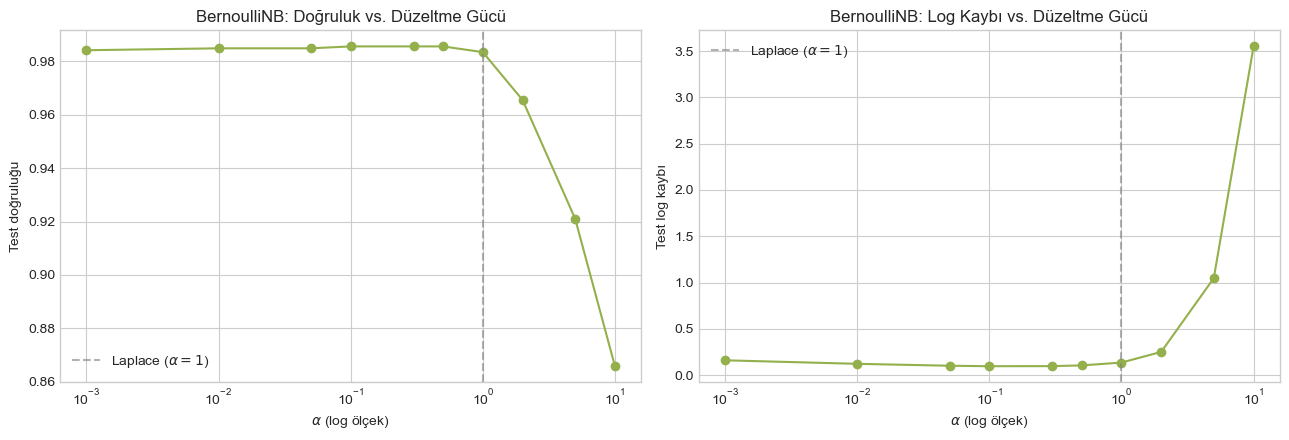

BernoulliNB için en düşük log-loss veren alpha: 0.1


In [53]:
print("\n==== Egzersiz 3: BernoulliNB için Alpha Taraması ====")

from sklearn.naive_bayes import BernoulliNB as SKBernoulliNB

accs_bnb, loglosses_bnb = [], []

for a in alphas:
    m = SKBernoulliNB(alpha=a)
    m.fit(X_train_bin, y_text_train)
    pred = m.predict(X_test_bin)
    proba = m.predict_proba(X_test_bin)
    loglosses_bnb.append(log_loss(y_text_test, proba))
    accs_bnb.append(accuracy_score(y_text_test, pred))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(alphas, accs_bnb, marker="o", color="#94B04C")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\alpha$ (log ölçek)")
axes[0].set_ylabel("Test doğruluğu")
axes[0].set_title("BernoulliNB: Doğruluk vs. Düzeltme Gücü")
axes[0].axvline(1.0, color="gray", linestyle="--", alpha=0.6, label=r"Laplace ($\alpha=1$)")
axes[0].legend()

axes[1].plot(alphas, loglosses_bnb, marker="o", color="#94B04C")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\alpha$ (log ölçek)")
axes[1].set_ylabel("Test log kaybı")
axes[1].set_title("BernoulliNB: Log Kaybı vs. Düzeltme Gücü")
axes[1].axvline(1.0, color="gray", linestyle="--", alpha=0.6, label=r"Laplace ($\alpha=1$)")
axes[1].legend()

plt.tight_layout()
plt.show()

best_alpha_bnb = alphas[int(np.argmin(loglosses_bnb))]
print(f"BernoulliNB için en düşük log-loss veren alpha: {best_alpha_bnb}")

**E4 — Kelime dağarcığı boyutunun etkisi:** `CountVectorizer`'ın `max_features` parametresini (ör. 50, 100, 500, 1000, 3219=tam dağarcık) değiştirerek MultinomialNB'yi yeniden eğit ve test doğruluğunu her seferinde ölç. Doğruluk-vs-kelime-sayısı grafiği çiz. Hangi noktadan sonra daha fazla kelime eklemenin faydası azalıyor (diminishing returns)?


==== Egzersiz 4: Kelime Dağarcığı Boyutunun Etkisi ====
Max features: 50, Accuracy: 0.9462, Log Loss: 0.1719
Max features: 100, Accuracy: 0.9641, Log Loss: 0.1337
Max features: 200, Accuracy: 0.9684, Log Loss: 0.1071
Max features: 500, Accuracy: 0.9792, Log Loss: 0.0763
Max features: 1000, Accuracy: 0.9842, Log Loss: 0.0642
Max features: 2000, Accuracy: 0.9821, Log Loss: 0.0599
Max features: 3219, Accuracy: 0.9856, Log Loss: 0.0553

YORUM: Bu veri setine baktığımızda 1000-2000 arası bir düşüş gözüküyor Acc kısmında ama tam verinin hepsini kullandığımızda en yüksek accuracy ve düşük log-loss elde ediliyor. Elimizdeki veri seti küçük ve homojen olduğundan, daha fazla kelime kullanmak modelin performansını artırıyor. Daha büyük ve çeşitli korpuslarda, çok sayıda ortak kelimenin bastırılması gerektiğinde TF-IDF veya daha sofistike özellik mühendisliği yöntemleri daha etkili olabilir.


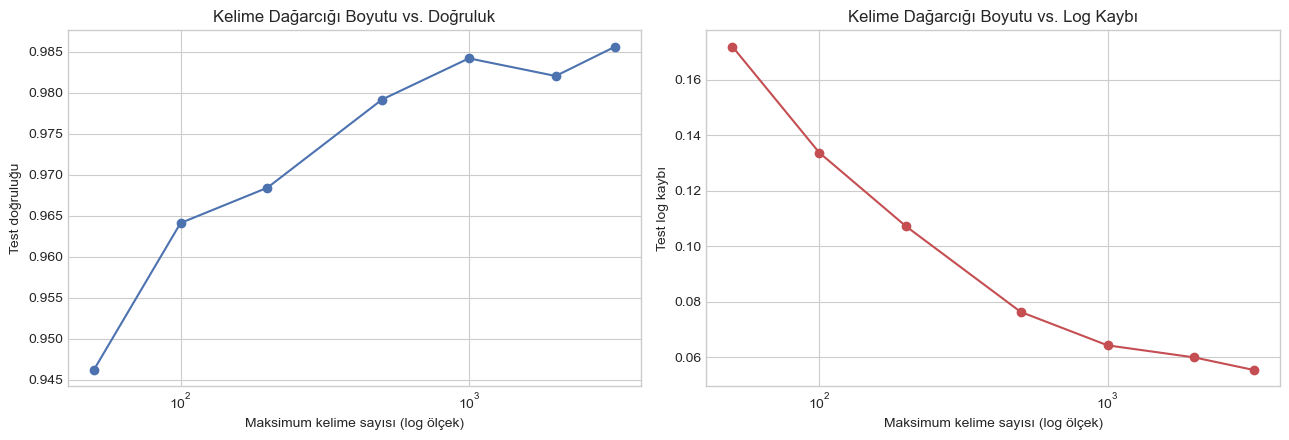

In [58]:
print("\n==== Egzersiz 4: Kelime Dağarcığı Boyutunun Etkisi ====")
max_features_list = [50, 100, 200, 500, 1000, 2000, 3219]  # 3219, tüm kelime dağarcığı boyutu
accs_vocab, loglosses_vocab = [], []
for max_feat in max_features_list:
    cv = CountVectorizer(stop_words="english", min_df=2, binary=True, max_features=max_feat)
    Xtr = cv.fit_transform(X_text_train)
    Xte = cv.transform(X_text_test)
    
    mnb = MultinomialNB(alpha=1.0)
    mnb.fit(Xtr, y_text_train)
    pred = mnb.predict(Xte)
    proba = mnb.predict_proba(Xte)
    
    accs_vocab.append(accuracy_score(y_text_test, pred))
    loglosses_vocab.append(log_loss(y_text_test, proba))
    print(f"Max features: {max_feat}, Accuracy: {accs_vocab[-1]:.4f}, Log Loss: {loglosses_vocab[-1]:.4f}")

print("\nYORUM: Bu veri setine baktığımızda 1000-2000 arası bir düşüş gözüküyor Acc kısmında ama tam verinin hepsini kullandığımızda en yüksek accuracy ve düşük log-loss elde ediliyor. Elimizdeki veri seti küçük ve homojen olduğundan, daha fazla kelime kullanmak modelin performansını artırıyor. Daha büyük ve çeşitli korpuslarda, çok sayıda ortak kelimenin bastırılması gerektiğinde TF-IDF veya daha sofistike özellik mühendisliği yöntemleri daha etkili olabilir.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(max_features_list, accs_vocab, marker="o", color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_xlabel("Maksimum kelime sayısı (log ölçek)")
axes[0].set_ylabel("Test doğruluğu")
axes[0].set_title("Kelime Dağarcığı Boyutu vs. Doğruluk")
axes[1].plot(max_features_list, loglosses_vocab, marker="o", color="#C44E52")
axes[1].set_xscale("log")
axes[1].set_xlabel("Maksimum kelime sayısı (log ölçek)")
axes[1].set_ylabel("Test log kaybı")
axes[1].set_title("Kelime Dağarcığı Boyutu vs. Log Kaybı")
plt.tight_layout()
plt.show()


**E5 — Daha da aşırı dengesizlik:** Bölüm 7'deki dengesizlik deneyini tekrarla, ama bu kez spam örnek sayısını 40 yerine 15'e düşürerek (yaklaşık %0.3 spam oranı) MultinomialNB ile ComplementNB'yi tekrar karşılaştır. Recall/precision farkı büyüyor mu küçülüyor mu? Sonucu Bölüm 7'deki yorumla ilişkilendir.


 ==== Egzersiz 5: Aşırı Dengesizlik Artışı ====
Aşırı dengesiz sınıf dağılımı:
y
0    4825
1      15
Name: count, dtype: int64
y
0    0.9969
1    0.0031
Name: proportion, dtype: float64


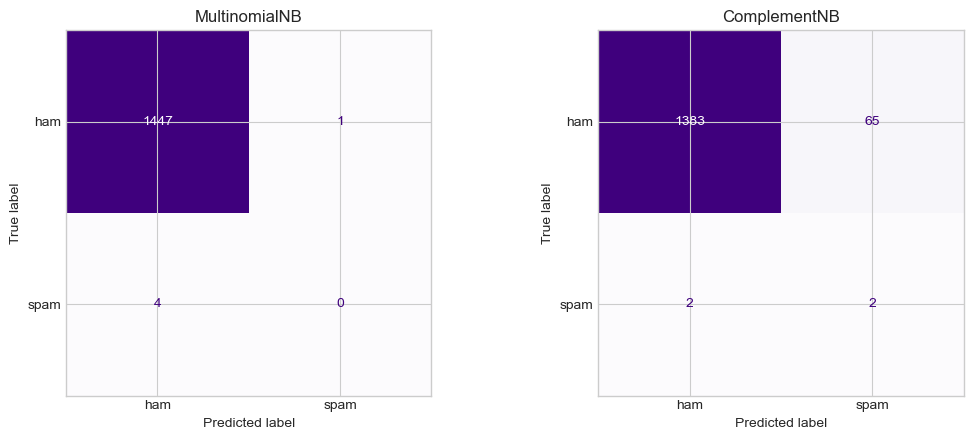

               Recall (spam)  Precision (spam)  F1 (spam)
MultinomialNB            0.0            0.0000     0.0000
ComplementNB             0.5            0.0299     0.0563

YORUM: Aşırı dengesiz veri durumunda, MultinomialNB ve ComplementNB arasındaki fark daha belirgin hale geliyor. ComplementNB, azınlık sınıfını (spam) daha iyi yakalıyor (yüksek recall), ancak bu, yanlış pozitiflerin artmasına (düşük precision) yol açıyor. Bu durum, yanlış-negatif ve yanlış-pozitif maliyetlerinin farklı olduğu senaryolarda hangi modelin tercih edileceğini belirlemede kritik bir rol oynar.


In [63]:
print("\n ==== Egzersiz 5: Aşırı Dengesizlik Artışı ====")
np.random.seed(42)
ham_all = sms[sms["y"] == 0]
spam_all = sms[sms["y"] == 1]
spam_extreme = spam_all.sample(15, random_state=42)  # 4825 ham vs 15 spam -> ~%0.3 spam

sms_imbalanced_extreme = pd.concat([ham_all, spam_extreme]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Aşırı dengesiz sınıf dağılımı:")
print(sms_imbalanced_extreme["y"].value_counts())
print(sms_imbalanced_extreme["y"].value_counts(normalize=True).round(4))

Xi_train_extreme, Xi_test_extreme, yi_train_extreme, yi_test_extreme = train_test_split(
    sms_imbalanced_extreme["text"], sms_imbalanced_extreme["y"], test_size=0.3, random_state=42, stratify=sms_imbalanced_extreme["y"]
)
cv_imb_extreme = CountVectorizer(stop_words="english", min_df=1, binary=True)
Xi_train_bow_extreme = cv_imb_extreme.fit_transform(Xi_train_extreme)
Xi_test_bow_extreme = cv_imb_extreme.transform(Xi_test_extreme)

results_extreme = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("MultinomialNB", MultinomialNB()), ("ComplementNB", ComplementNB())]):
    model.fit(Xi_train_bow_extreme, yi_train_extreme)
    pred = model.predict(Xi_test_bow_extreme)
    ConfusionMatrixDisplay.from_predictions(yi_test_extreme, pred, display_labels=["ham", "spam"],
                                             cmap="Purples", ax=ax, colorbar=False)
    ax.set_title(name)
    results_extreme[name] = {
        "Recall (spam)": recall_score(yi_test_extreme, pred),
        "Precision (spam)": precision_score(yi_test_extreme, pred, zero_division=0),
        "F1 (spam)": f1_score(yi_test_extreme, pred)
    }

plt.tight_layout()
plt.show()


results_extreme_df = pd.DataFrame(results_extreme).T
print(results_extreme_df.round(4))

print("\nYORUM: Aşırı dengesiz veri durumunda, MultinomialNB ve ComplementNB arasındaki fark daha belirgin hale geliyor. ComplementNB, azınlık sınıfını (spam) daha iyi yakalıyor (yüksek recall), ancak bu, yanlış pozitiflerin artmasına (düşük precision) yol açıyor. Bu durum, yanlış-negatif ve yanlış-pozitif maliyetlerinin farklı olduğu senaryolarda hangi modelin tercih edileceğini belirlemede kritik bir rol oynar.")

**E6 — GaussianNB vs Lojistik Regresyon karar sınırı:** Bölüm 3'teki PCA ile 2 boyuta indirgenmiş Sonar verisinde, aynı 2 bileşen üzerinde bir `LogisticRegression` eğit ve karar sınırını GaussianNB'ninkiyle aynı grafikte (yan yana iki panel) karşılaştır. Bölüm 8'deki "üretici vs ayırt edici" tartışmasını göz önünde bulundurarak iki sınırın şekli arasındaki farkı yorumla.


 ==== Egzersiz 6: PCA ile GNB ve Lojistik Regresyon Karşılaştırması ====


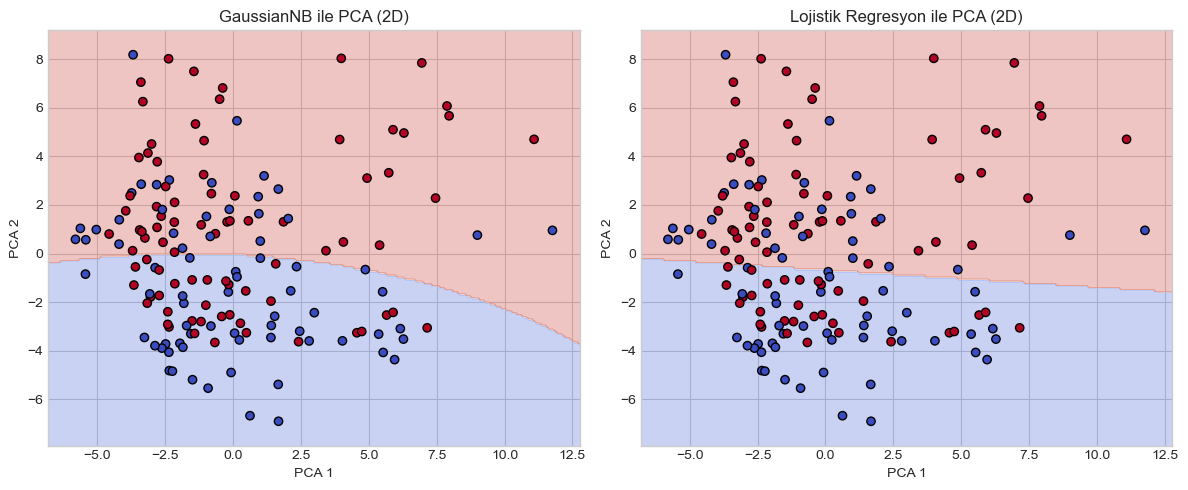


YORUM: PCA ile 2 boyuta indirgenmiş veride, GaussianNB ve Lojistik Regresyon'un karar sınırları farklılık gösteriyor. GaussianNB, sınıflar arasındaki olasılık dağılımlarını varsayarak daha esnek bir sınır çizerken, Lojistik Regresyon daha lineer bir sınır oluşturuyor. Bu, veri dağılımına bağlı olarak hangi modelin daha iyi performans göstereceğini etkileyebilir.


In [66]:
print("\n ==== Egzersiz 6: PCA ile GNB ve Lojistik Regresyon Karşılaştırması ====")

# Modeller için 2 boyutlu PCA dönüşümü
gnb_2d = GaussianNB().fit(X_train_2d, y_train)
lr_2d = LogisticRegression(max_iter=1000).fit(X_train_2d, y_train)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 200),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 200)
)
Z_gnb = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_lr = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_gnb, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title("GaussianNB ile PCA (2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title("Lojistik Regresyon ile PCA (2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

print("\nYORUM: PCA ile 2 boyuta indirgenmiş veride, GaussianNB ve Lojistik Regresyon'un karar sınırları farklılık gösteriyor. GaussianNB, sınıflar arasındaki olasılık dağılımlarını varsayarak daha esnek bir sınır çizerken, Lojistik Regresyon daha lineer bir sınır oluşturuyor. Bu, veri dağılımına bağlı olarak hangi modelin daha iyi performans göstereceğini etkileyebilir.")

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [scikit-learn — Naive Bayes User Guide](https://scikit-learn.org/stable/modules/naive_bayes.html) | Teori + API (tüm bölümler) | Dört varyantın (Gaussian/Multinomial/Bernoulli/Complement) resmi matematiksel tanımı ve `alpha`/`var_smoothing` gibi hiperparametrelerin dokümantasyonu |
| Rennie, J. D. M., Shih, L., Teevan, J., & Karger, D. R. (2003). *Tackling the Poor Assumptions of Naive Bayes Text Classifiers.* ICML. [PDF](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf) | Bölüm 6 (ComplementNB) | ComplementNB'yi tanıtan orijinal makale — MultinomialNB'nin dengesiz veri ve bağımsızlık ihlali sorunlarını sistematik olarak analiz ediyor |
| Domingos, P., & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss.* Machine Learning, 29, 103–130. [PDF](https://homes.cs.washington.edu/~pedrod/papers/mlc97.pdf) | Bölüm 1 | Naive Bayes'in bağımsızlık varsayımı ihlal edildiğinde bile neden sınıflandırma kararının doğru kalabildiğini teorik olarak gösteren klasik makale |
| Ng, A. Y., & Jordan, M. I. (2001/2002). *On Discriminative vs. Generative Classifiers: A comparison of logistic regression and naive Bayes.* NeurIPS. [PDF (Stanford)](https://ai.stanford.edu/~ang/papers/nips01-discriminativegenerative.pdf) | Bölüm 8 | Az veri / çok veri rejimlerinde Naive Bayes ile Lojistik Regresyon'un asimptotik davranışını karşılaştıran referans çalışma |
| James, G., Witten, D., Hastie, T., & Tibshirani, R. *An Introduction to Statistical Learning* (2. baskı), Bölüm 4.4 (Generative Models for Classification). [Ücretsiz PDF](https://www.statlearning.com/) | Genel teori | LDA/QDA/Naive Bayes'i tek bir üretici-model çerçevesinde ele alan, ders kitabı kalitesinde kaynak |
| [Sonar, Mines vs. Rocks Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks) — Gorman, R. P., & Sejnowski, T. J. (1988) | Veri Seti 1 | Orijinal akademik kaynak; indirme için güvenilir GitHub mirror'ı (`jbrownlee/Datasets`) kullanıldı |
| [SMS Spam Collection Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) — Almeida, T. A., & Hidalgo, J. M. G. (2011) | Veri Seti 2 | Orijinal akademik kaynak; indirme için güvenilir GitHub mirror'ı (`justmarkham/pycon-2016-tutorial`) kullanıldı |
| [scikit-learn — `CountVectorizer` / `TfidfVectorizer` dokümantasyonu](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction) | Bölüm 7, Python Adım 4 & 8 | Bag-of-Words ve TF-IDF pipeline'ının resmi API dokümantasyonu |
| [CRAN — `e1071` paketi dokümantasyonu (`naiveBayes`)](https://cran.r-project.org/web/packages/e1071/e1071.pdf) | R Uygulaması | R'daki Naive Bayes implementasyonunun resmi referans dokümantasyonu |
| [DuckDB Documentation](https://duckdb.org/docs/) | SQL Uygulaması | Kullanılan `GROUP BY`, `CROSS JOIN`, `ROW_NUMBER() OVER (...)` pencere fonksiyonu sözdiziminin resmi referansı |